RF - Specilized models

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, f1_score, accuracy_score,
    precision_score, confusion_matrix
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION & FEATURE DEFINITION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP    = {"NB": 0, "BH": 1, "DB": 2}
CLASSES      = [0, 1, 2]

# The WS20 Optimized Feature List (Zero Multicollinearity, Max Predictive Power)
G_LIST = [
    # Primary BH Detectors
    "pNN50_Ratio",             
    "pNN50_Delta",             
    "HF_Ratio",                
    
    # Secondary HRV / ANS Features
    "RMSSD_Ratio",             
    "Mean_RR_Ratio",           
    "Shannon_Entropy_Ratio",   

    # Deep Breathing (DB) Isolators
    "EDR_Std_Amp_Ratio",       
    "EDR_Mean_Amp_Delta"       
]

# ═══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION WITH PERSONALIZED BAYESIAN SCALING
# ═══════════════════════════════════════════════════════════════════════════════

def run_calibrated_loso(df):
    print("\n" + "=" * 95)
    print("LOSO EVALUATION: WS20 OPTIMIZED (8 Features) + PERSONAL CALIBRATION")
    print("=" * 95)

    df["y"] = df["Category"].map(CLASS_MAP)
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    header = (f"  {'Sub':6s} | {'N_NB':>4} | {'N_BH':>4} | {'N_DB':>4} | "
              f"{'Acc':>5} | {'Mac_Prec':>8} | {'Mac_Rec':>7} | {'Mac_F1':>6}")
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        test_df = df[te_mask].copy()
        if len(test_df) == 0:
            continue

        # ── 1. Train on ALL OTHER Subjects ──────────────────────────────────
        X_tr = df.loc[tr_mask, G_LIST].fillna(0).values
        y_tr = df.loc[tr_mask, "y"].values

        # Base RF with automatic class balancing
        base_rf = RandomForestClassifier(
            n_estimators=300,            # 300 is optimal for 8 features
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",     # Automatically handles the heavy NB skew
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        # Isotonic calibration applied to multi-class (One-vs-Rest internally)
        clf = CalibratedClassifierCV(base_rf, method="isotonic", cv=3)
        clf.fit(X_tr, y_tr)

        # ── 2. Identify Personal Calibration Baseline (Resting State) ───────
        # Find up to the first 5 NB windows to establish the subject's resting bias
        nb_calib_idx = test_df[test_df["y"] == 0].head(5).index
        
        if len(nb_calib_idx) > 0:
            X_calib = df.loc[nb_calib_idx, G_LIST].fillna(0).values
            # Get the model's average probability distribution during known rest
            base_probs = clf.predict_proba(X_calib).mean(axis=0) 
        else:
            # Fallback if no NB data exists at the start (extremely rare)
            base_probs = np.array([0.34, 0.33, 0.33])
            
        # Add a tiny epsilon to prevent division by zero in the scaling math
        epsilon = 1e-5
        base_probs = np.clip(base_probs, epsilon, 1.0)

        # ── 3. Evaluate on ALL Held-Out Windows ─────────────────────────────
        X_eval = test_df[G_LIST].fillna(0).values
        y_eval = test_df["y"].values

        # Step A: Get raw probabilities from the generic calibrated model
        eval_prob_raw = clf.predict_proba(X_eval)
        
        # Step B: Scale probabilities (Divide raw probs by the subject's baseline bias)
        eval_prob_scaled = eval_prob_raw / base_probs
        
        # Step C: Re-normalize so probabilities sum perfectly to 1.0 per row
        eval_prob_final = eval_prob_scaled / eval_prob_scaled.sum(axis=1, keepdims=True)
        
        # Step D: Make the final prediction based on the highest personalized probability
        eval_pred = np.argmax(eval_prob_final, axis=1)

        # Store for global metrics
        all_y_true.extend(y_eval.tolist())
        all_y_prob.extend(eval_prob_final.tolist())
        all_y_pred.extend(eval_pred.tolist())

        # ── 4. Calculate Subject-Level Metrics ──────────────────────────────
        acc  = accuracy_score(y_eval, eval_pred)
        prec = precision_score(y_eval, eval_pred, average='macro', zero_division=0)
        rec  = recall_score(y_eval, eval_pred, average='macro', zero_division=0)
        f1   = f1_score(y_eval, eval_pred, average='macro', zero_division=0)
        
        n_nb = (y_eval == 0).sum()
        n_bh = (y_eval == 1).sum()
        n_db = (y_eval == 2).sum()

        print(f"  {test_sub:6s} | {n_nb:>4} | {n_bh:>4} | {n_db:>4} | "
              f"{acc:>5.3f} | {prec:>8.3f} | {rec:>7.3f} | {f1:>6.3f}")

    # ── Aggregate Global Results ────────────────────────────────────────────
    if len(all_y_true) == 0:
        print("\n  [!] No valid evaluation windows found.")
        return

    yt = np.array(all_y_true)
    yp = np.array(all_y_prob)
    yd = np.array(all_y_pred)

    # One-Hot Encode true labels for AUROC & AUPRC
    yt_ohe = label_binarize(yt, classes=CLASSES)

    auroc = roc_auc_score(yt_ohe, yp, multi_class='ovr', average='macro')
    auprc = average_precision_score(yt_ohe, yp, average='macro')
    
    acc   = accuracy_score(yt, yd)
    prec  = precision_score(yt, yd, average='macro', zero_division=0)
    rec   = recall_score(yt, yd, average='macro', zero_division=0)
    f1    = f1_score(yt, yd, average='macro', zero_division=0)
    cm    = confusion_matrix(yt, yd, labels=CLASSES)

    print("\n  " + "─" * 65)
    print(f"  ── WS20 FINAL PERFORMANCE (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR) = {auroc:.4f}")
    print(f"     AUPRC       = {auprc:.4f}")
    print(f"     Accuracy    = {acc:.3f}")
    print(f"     Recall      = {rec:.3f}")
    print(f"     Precision   = {prec:.3f}")
    print(f"     F1 Score    = {f1:.3f}")
    
    print("\n     ── OVERALL CONFUSION MATRIX ──")
    print(f"                 Pred NB (0)   Pred BH (1)   Pred DB (2)")
    print(f"   Actual NB (0) {cm[0,0]:<13} {cm[0,1]:<13} {cm[0,2]:<13}")
    print(f"   Actual BH (1) {cm[1,0]:<13} {cm[1,1]:<13} {cm[1,2]:<13}")
    print(f"   Actual DB (2) {cm[2,0]:<13} {cm[2,1]:<13} {cm[2,2]:<13}")
    print("  " + "─" * 65)


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    if not os.path.exists(INPUT_CSV):
        print(f"\n[!] ERROR: {INPUT_CSV} not found in the current directory.")
        return

    print(f"Loading {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)
    
    # Ensure all optimized features exist in the dataset
    missing = [f for f in G_LIST if f not in df.columns]
    if missing:
        print(f"\n[!] ERROR: Missing features in CSV: {missing}")
        return

    print(f"\nDataset Overview: {len(df):,} total windows")
    print(f"  Subjects = {df['Subject'].nunique()}")
    for cat in CLASS_MAP.keys():
        count = (df['Category'] == cat).sum()
        print(f"  {cat} = {count:,}")

    # Run the rigorous evaluation
    run_calibrated_loso(df)

if __name__ == "__main__":
    main()

Loading BH_DB_Features_WS20.csv ...

Dataset Overview: 28,090 total windows
  Subjects = 41
  NB = 21,529
  BH = 3,505
  DB = 3,056

LOSO EVALUATION: WS20 OPTIMIZED (8 Features) + PERSONAL CALIBRATION
  Sub    | N_NB | N_BH | N_DB |   Acc | Mac_Prec | Mac_Rec | Mac_F1
  ─────────────────────────────────────────────────────────────────
  S_10   |  469 |   40 |   75 | 0.430 |    0.497 |   0.745 |  0.413
  S_11   |  497 |   90 |   72 | 0.411 |    0.526 |   0.720 |  0.420
  S_14   |  497 |   90 |   79 | 0.365 |    0.493 |   0.605 |  0.367
  S_15   |  512 |   90 |   71 | 0.410 |    0.505 |   0.650 |  0.404
  S_16   |  493 |   90 |   76 | 0.410 |    0.539 |   0.737 |  0.430
  S_18   |  487 |   76 |   80 | 0.470 |    0.445 |   0.519 |  0.366
  S_19   |  456 |   90 |   81 | 0.301 |    0.499 |   0.603 |  0.316
  S_20   |  492 |   65 |   72 | 0.248 |    0.462 |   0.578 |  0.263
  S_21   |  514 |   90 |   71 | 0.347 |    0.491 |   0.638 |  0.353
  S_22   |  513 |   90 |   66 | 0.248 |    0.446 | 

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, f1_score, accuracy_score,
    precision_score, confusion_matrix
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION & FEATURE DEFINITION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP    = {"NB": 0, "BH": 1, "DB": 2}
CLASSES      = [0, 1, 2]

# The WS20 Optimized Feature List (8 Features)
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# ═══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION WITH ADVANCED METRICS & THRESHOLD OPTIMIZATION
# ═══════════════════════════════════════════════════════════════════════════════

def run_advanced_loso(df):
    print("\n" + "=" * 115)
    print("LOSO EVALUATION: WS20 OPTIMIZED | ADVANCED METRICS & DYNAMIC CALIBRATION THRESHOLDS")
    print("=" * 115)

    df["y"] = df["Category"].map(CLASS_MAP)
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    # Extremely detailed wide header
    header = (f"  {'Sub':6s} | {'N_NB':>4} | {'N_BH':>4} | {'N_DB':>4} | {'Thr_BH':>6} | "
              f"{'Acc':>5} | {'Mac_F1':>6} || {'BH_Prec':>7} | {'BH_Rec':>6} | {'BH_F1':>5} || "
              f"{'DB_Rec':>6} | {'DB_F1':>5}")
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        test_df = df[te_mask].copy()
        if len(test_df) == 0:
            continue

        # ── 1. Train on ALL OTHER Subjects ──────────────────────────────────
        X_tr = df.loc[tr_mask, G_LIST].fillna(0).values
        y_tr = df.loc[tr_mask, "y"].values

        base_rf = RandomForestClassifier(
            n_estimators=300,            
            min_samples_leaf=5,          
            max_features="sqrt",
            class_weight="balanced",     
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        
        clf = CalibratedClassifierCV(base_rf, method="isotonic", cv=3)
        clf.fit(X_tr, y_tr)

        # ── 2. Dynamic Threshold Calibration for BH ─────────────────────────
        # Find the optimal threshold for predicting a Breath Hold by testing 
        # what threshold yields the absolute best F1 score on the training folds.
        tr_probs = clf.predict_proba(X_tr)
        bh_probs_tr = tr_probs[:, 1]
        y_tr_bh = (y_tr == 1).astype(int)
        
        best_thr = 0.33 # Default to standard 1/3 probability
        best_bh_f1 = 0
        
        # Scan probabilities from 20% to 60%
        for thr in np.arange(0.20, 0.60, 0.02):
            preds = (bh_probs_tr >= thr).astype(int)
            f1 = f1_score(y_tr_bh, preds, zero_division=0)
            if f1 > best_bh_f1:
                best_bh_f1 = f1
                best_thr = thr

        # ── 3. Evaluate on Held-Out Subject using Custom Threshold ──────────
        X_eval = test_df[G_LIST].fillna(0).values
        y_eval = test_df["y"].values

        eval_prob = clf.predict_proba(X_eval)
        eval_pred = np.zeros(len(eval_prob), dtype=int)
        
        # Apply the calibrated threshold logic
        for i in range(len(eval_prob)):
            if eval_prob[i, 1] >= best_thr:
                eval_pred[i] = 1  # Predict BH if it meets the tuned threshold
            else:
                # If not BH, decide between Normal Breathing (0) and Deep Breathing (2)
                if eval_prob[i, 2] > eval_prob[i, 0]:
                    eval_pred[i] = 2
                else:
                    eval_pred[i] = 0

        # Store for global metrics
        all_y_true.extend(y_eval.tolist())
        all_y_prob.extend(eval_prob.tolist())
        all_y_pred.extend(eval_pred.tolist())

        # ── 4. Calculate Advanced Subject-Level Metrics ─────────────────────
        acc    = accuracy_score(y_eval, eval_pred)
        mac_f1 = f1_score(y_eval, eval_pred, average='macro', zero_division=0)
        
        # Class-Specific Metrics (We force labels=[0,1,2] so the arrays always align)
        prec_arr = precision_score(y_eval, eval_pred, labels=CLASSES, average=None, zero_division=0)
        rec_arr  = recall_score(y_eval, eval_pred, labels=CLASSES, average=None, zero_division=0)
        f1_arr   = f1_score(y_eval, eval_pred, labels=CLASSES, average=None, zero_division=0)
        
        bh_prec, bh_rec, bh_f1 = prec_arr[1], rec_arr[1], f1_arr[1]
        db_rec, db_f1          = rec_arr[2], f1_arr[2]
        
        n_nb = (y_eval == 0).sum()
        n_bh = (y_eval == 1).sum()
        n_db = (y_eval == 2).sum()

        print(f"  {test_sub:6s} | {n_nb:>4} | {n_bh:>4} | {n_db:>4} | {best_thr:>6.2f} | "
              f"{acc:>5.3f} | {mac_f1:>6.3f} || {bh_prec:>7.3f} | {bh_rec:>6.3f} | {bh_f1:>5.3f} || "
              f"{db_rec:>6.3f} | {db_f1:>5.3f}")

    # ── Aggregate Global Results ────────────────────────────────────────────
    if len(all_y_true) == 0:
        print("\n  [!] No valid evaluation windows found.")
        return

    yt = np.array(all_y_true)
    yp = np.array(all_y_prob)
    yd = np.array(all_y_pred)

    yt_ohe = label_binarize(yt, classes=CLASSES)

    auroc = roc_auc_score(yt_ohe, yp, multi_class='ovr', average='macro')
    auprc = average_precision_score(yt_ohe, yp, average='macro')
    
    acc   = accuracy_score(yt, yd)
    mac_f1= f1_score(yt, yd, average='macro', zero_division=0)
    
    prec_arr = precision_score(yt, yd, labels=CLASSES, average=None, zero_division=0)
    rec_arr  = recall_score(yt, yd, labels=CLASSES, average=None, zero_division=0)
    f1_arr   = f1_score(yt, yd, labels=CLASSES, average=None, zero_division=0)
    cm       = confusion_matrix(yt, yd, labels=CLASSES)

    print("\n  " + "─" * 65)
    print(f"  ── GLOBAL PERFORMANCE SUMMARY (WS20 OPTIMIZED) ──")
    print(f"     Global Accuracy : {acc:.3f}")
    print(f"     Macro AUROC     : {auroc:.4f}")
    print(f"     Macro AUPRC     : {auprc:.4f}")
    print(f"     Macro F1 Score  : {mac_f1:.3f}")
    
    print("\n  ── CLASS-SPECIFIC PERFORMANCE ──")
    print(f"     Target          | Precision | Recall  | F1 Score")
    print("     ----------------|-----------|---------|---------")
    print(f"     Normal (NB)     | {prec_arr[0]:>9.3f} | {rec_arr[0]:>7.3f} | {f1_arr[0]:>8.3f}")
    print(f"     Breath Hold (BH)| {prec_arr[1]:>9.3f} | {rec_arr[1]:>7.3f} | {f1_arr[1]:>8.3f}")
    print(f"     Deep Breath (DB)| {prec_arr[2]:>9.3f} | {rec_arr[2]:>7.3f} | {f1_arr[2]:>8.3f}")

    print("\n  ── OVERALL CONFUSION MATRIX ──")
    print(f"                 Pred NB (0)   Pred BH (1)   Pred DB (2)")
    print(f"   Actual NB (0) {cm[0,0]:<13} {cm[0,1]:<13} {cm[0,2]:<13}")
    print(f"   Actual BH (1) {cm[1,0]:<13} {cm[1,1]:<13} {cm[1,2]:<13}")
    print(f"   Actual DB (2) {cm[2,0]:<13} {cm[2,1]:<13} {cm[2,2]:<13}")
    print("  " + "─" * 65)

# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    if not os.path.exists(INPUT_CSV):
        print(f"\n[!] ERROR: {INPUT_CSV} not found.")
        return

    df = pd.read_csv(INPUT_CSV)
    run_advanced_loso(df)

if __name__ == "__main__":
    main()


LOSO EVALUATION: WS20 OPTIMIZED | ADVANCED METRICS & DYNAMIC CALIBRATION THRESHOLDS
  Sub    | N_NB | N_BH | N_DB | Thr_BH |   Acc | Mac_F1 || BH_Prec | BH_Rec | BH_F1 || DB_Rec | DB_F1
  ───────────────────────────────────────────────────────────────────────────────────────────────────
  S_10   |  469 |   40 |   75 |   0.40 | 0.882 |  0.765 ||   0.588 |  0.750 | 0.659 ||  0.720 | 0.701
  S_11   |  497 |   90 |   72 |   0.44 | 0.912 |  0.839 ||   0.888 |  0.967 | 0.926 ||  0.583 | 0.646
  S_14   |  497 |   90 |   79 |   0.42 | 0.878 |  0.754 ||   0.986 |  0.756 | 0.855 ||  0.418 | 0.468
  S_15   |  512 |   90 |   71 |   0.42 | 0.944 |  0.900 ||   0.960 |  0.800 | 0.873 ||  0.958 | 0.861
  S_16   |  493 |   90 |   76 |   0.42 | 0.930 |  0.875 ||   0.905 |  0.956 | 0.930 ||  0.618 | 0.740
  S_18   |  487 |   76 |   80 |   0.42 | 0.840 |  0.570 ||   0.000 |  0.000 | 0.000 ||  0.725 | 0.806
  S_19   |  456 |   90 |   81 |   0.40 | 0.876 |  0.776 ||   1.000 |  0.422 | 0.594 ||  0.840 | 0.8

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, f1_score, accuracy_score,
    precision_score, confusion_matrix
)
import scipy.signal

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION & FEATURE DEFINITION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP    = {"NB": 0, "BH": 1, "DB": 2}
CLASSES      = [0, 1, 2]

# The WS20 Optimized Feature List (8 Features)
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# ═══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION WITH ADVANCED METRICS & THRESHOLD OPTIMIZATION
# ═══════════════════════════════════════════════════════════════════════════════

def run_advanced_loso(df):
    print("\n" + "=" * 115)
    print("LOSO EVALUATION: WS20 OPTIMIZED | ADVANCED METRICS & DYNAMIC CALIBRATION THRESHOLDS + TEMPORAL SMOOTHING and DUAL THRESHOLD OPTIMIZATION")
    print("=" * 115)

    df["y"] = df["Category"].map(CLASS_MAP)
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    # Extremely detailed wide header
    header = (f"  {'Sub':6s} | {'N_NB':>4} | {'N_BH':>4} | {'N_DB':>4} | {'Thr_BH':>6} | "
              f"{'Acc':>5} | {'Mac_F1':>6} || {'BH_Prec':>7} | {'BH_Rec':>6} | {'BH_F1':>5} || "
              f"{'DB_Rec':>6} | {'DB_F1':>5}")
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        test_df = df[te_mask].copy()
        if len(test_df) == 0:
            continue

        # ── 1. Train on ALL OTHER Subjects ──────────────────────────────────
        X_tr = df.loc[tr_mask, G_LIST].fillna(0).values
        y_tr = df.loc[tr_mask, "y"].values

        base_rf = RandomForestClassifier(
            n_estimators=300,            
            min_samples_leaf=5,          
            max_features="sqrt",
            class_weight="balanced",     
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        
        clf = CalibratedClassifierCV(base_rf, method="isotonic", cv=3)
        clf.fit(X_tr, y_tr)

        # ── 2. DUAL Dynamic Threshold Calibration (BH and DB) ───────────────
        tr_probs = clf.predict_proba(X_tr)
        
        # Optimize BH Threshold
        y_tr_bh = (y_tr == 1).astype(int)
        best_bh_thr, best_bh_f1 = 0.33, 0
        for thr in np.arange(0.20, 0.60, 0.02):
            f1 = f1_score(y_tr_bh, (tr_probs[:, 1] >= thr).astype(int), zero_division=0)
            if f1 > best_bh_f1:
                best_bh_f1, best_bh_thr = f1, thr
                
        # Optimize DB Threshold (Independent from BH)
        y_tr_db = (y_tr == 2).astype(int)
        best_db_thr, best_db_f1 = 0.33, 0
        for thr in np.arange(0.20, 0.60, 0.02):
            f1 = f1_score(y_tr_db, (tr_probs[:, 2] >= thr).astype(int), zero_division=0)
            if f1 > best_db_f1:
                best_db_f1, best_db_thr = f1, thr

        # ── 3. Evaluate on Held-Out Subject with Temporal Smoothing ─────────
        X_eval = test_df[G_LIST].fillna(0).values
        y_eval = test_df["y"].values

        eval_prob = clf.predict_proba(X_eval)
        raw_preds = np.zeros(len(eval_prob), dtype=int)
        
        # Apply Dual Thresholds
        for i in range(len(eval_prob)):
            # Priority 1: Did it cross the tuned Breath Hold threshold?
            if eval_prob[i, 1] >= best_bh_thr:
                raw_preds[i] = 1
            # Priority 2: Did it cross the tuned Deep Breathing threshold?
            elif eval_prob[i, 2] >= best_db_thr:
                raw_preds[i] = 2
            # Default: Normal Breathing
            else:
                raw_preds[i] = 0

        # ── Apply Temporal Smoothing (Median Filter) ──
        # Uses a rolling window of 3 to smooth out isolated 1-window glitches
        eval_pred = scipy.signal.medfilt(raw_preds, kernel_size=3).astype(int)

        # ── 4. Calculate Advanced Subject-Level Metrics ─────────────────────
        acc    = accuracy_score(y_eval, eval_pred)
        mac_f1 = f1_score(y_eval, eval_pred, average='macro', zero_division=0)
        
        # Class-Specific Metrics (We force labels=[0,1,2] so the arrays always align)
        prec_arr = precision_score(y_eval, eval_pred, labels=CLASSES, average=None, zero_division=0)
        rec_arr  = recall_score(y_eval, eval_pred, labels=CLASSES, average=None, zero_division=0)
        f1_arr   = f1_score(y_eval, eval_pred, labels=CLASSES, average=None, zero_division=0)
        
        bh_prec, bh_rec, bh_f1 = prec_arr[1], rec_arr[1], f1_arr[1]
        db_rec, db_f1          = rec_arr[2], f1_arr[2]
        
        n_nb = (y_eval == 0).sum()
        n_bh = (y_eval == 1).sum()
        n_db = (y_eval == 2).sum()

        # FIXED variable name here: best_bh_thr instead of best_thr
        print(f"  {test_sub:6s} | {n_nb:>4} | {n_bh:>4} | {n_db:>4} | {best_bh_thr:>6.2f} | "
              f"{acc:>5.3f} | {mac_f1:>6.3f} || {bh_prec:>7.3f} | {bh_rec:>6.3f} | {bh_f1:>5.3f} || "
              f"{db_rec:>6.3f} | {db_f1:>5.3f}")

        # Store for global metrics
        all_y_true.extend(y_eval.tolist())
        all_y_prob.extend(eval_prob.tolist())
        all_y_pred.extend(eval_pred.tolist())

    # ── Aggregate Global Results ────────────────────────────────────────────
    if len(all_y_true) == 0:
        print("\n  [!] No valid evaluation windows found.")
        return

    yt = np.array(all_y_true)
    yp = np.array(all_y_prob)
    yd = np.array(all_y_pred)

    yt_ohe = label_binarize(yt, classes=CLASSES)

    auroc = roc_auc_score(yt_ohe, yp, multi_class='ovr', average='macro')
    auprc = average_precision_score(yt_ohe, yp, average='macro')
    
    acc   = accuracy_score(yt, yd)
    mac_f1= f1_score(yt, yd, average='macro', zero_division=0)
    
    prec_arr = precision_score(yt, yd, labels=CLASSES, average=None, zero_division=0)
    rec_arr  = recall_score(yt, yd, labels=CLASSES, average=None, zero_division=0)
    f1_arr   = f1_score(yt, yd, labels=CLASSES, average=None, zero_division=0)
    cm       = confusion_matrix(yt, yd, labels=CLASSES)

    print("\n  " + "─" * 65)
    print(f"  ── GLOBAL PERFORMANCE SUMMARY (WS20 OPTIMIZED) ──")
    print(f"     Global Accuracy : {acc:.3f}")
    print(f"     Macro AUROC     : {auroc:.4f}")
    print(f"     Macro AUPRC     : {auprc:.4f}")
    print(f"     Macro F1 Score  : {mac_f1:.3f}")
    
    print("\n  ── CLASS-SPECIFIC PERFORMANCE ──")
    print(f"     Target          | Precision | Recall  | F1 Score")
    print("     ----------------|-----------|---------|---------")
    print(f"     Normal (NB)     | {prec_arr[0]:>9.3f} | {rec_arr[0]:>7.3f} | {f1_arr[0]:>8.3f}")
    print(f"     Breath Hold (BH)| {prec_arr[1]:>9.3f} | {rec_arr[1]:>7.3f} | {f1_arr[1]:>8.3f}")
    print(f"     Deep Breath (DB)| {prec_arr[2]:>9.3f} | {rec_arr[2]:>7.3f} | {f1_arr[2]:>8.3f}")

    print("\n  ── OVERALL CONFUSION MATRIX ──")
    print(f"                 Pred NB (0)   Pred BH (1)   Pred DB (2)")
    print(f"   Actual NB (0) {cm[0,0]:<13} {cm[0,1]:<13} {cm[0,2]:<13}")
    print(f"   Actual BH (1) {cm[1,0]:<13} {cm[1,1]:<13} {cm[1,2]:<13}")
    print(f"   Actual DB (2) {cm[2,0]:<13} {cm[2,1]:<13} {cm[2,2]:<13}")
    print("  " + "─" * 65)

# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    if not os.path.exists(INPUT_CSV):
        print(f"\n[!] ERROR: {INPUT_CSV} not found.")
        return

    df = pd.read_csv(INPUT_CSV)
    run_advanced_loso(df)

if __name__ == "__main__":
    main()


LOSO EVALUATION: WS20 OPTIMIZED | ADVANCED METRICS & DYNAMIC CALIBRATION THRESHOLDS + TEMPORAL SMOOTHING and DUAL THRESHOLD OPTIMIZATION
  Sub    | N_NB | N_BH | N_DB | Thr_BH |   Acc | Mac_F1 || BH_Prec | BH_Rec | BH_F1 || DB_Rec | DB_F1
  ───────────────────────────────────────────────────────────────────────────────────────────────────
  S_10   |  469 |   40 |   75 |   0.40 | 0.878 |  0.742 ||   0.547 |  0.725 | 0.624 ||  0.640 | 0.667
  S_11   |  497 |   90 |   72 |   0.44 | 0.918 |  0.848 ||   0.906 |  0.967 | 0.935 ||  0.569 | 0.661
  S_14   |  497 |   90 |   79 |   0.42 | 0.883 |  0.762 ||   1.000 |  0.767 | 0.868 ||  0.418 | 0.478
  S_15   |  512 |   90 |   71 |   0.42 | 0.947 |  0.908 ||   0.961 |  0.811 | 0.880 ||  0.958 | 0.877
  S_16   |  493 |   90 |   76 |   0.42 | 0.935 |  0.885 ||   0.905 |  0.956 | 0.930 ||  0.658 | 0.769
  S_18   |  487 |   76 |   80 |   0.42 | 0.843 |  0.573 ||   0.000 |  0.000 | 0.000 ||  0.725 | 0.811
  S_19   |  456 |   90 |   81 |   0.40 | 0.880

In [ ]:
"""
rf_bh_loso_ws20.py
══════════════════════════════════════════════════════════════════════════════
Definitive Random Forest classifier for Breath-Hold (BH) event prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation
Calibration: OOB-Youden personal threshold calibration per test subject

Architecture decisions (all data-driven, see analysis):
  • class_weight = 'balanced'  (NB:BH:DB ≈ 1:6:7)
  • n_estimators = 400, oob_score = True — OOB probabilities give a held-out
    BH/DB sensitivity curve without an extra CV loop.
  • Feature winsorising at training P1–P99 per fold (no leakage).
  • Personal threshold calibration via Youden-J index:
      tau*(class c) = argmax_τ [ OOB_sens_c(τ) − personal_FPR_c(τ) ]
  • Temporal Smoothing: 3-window median filter to eliminate high-frequency 
    prediction jitter.
  • Optimized 8-Feature List to completely eliminate VIF/multicollinearity.
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List (8 Features - Zero Multicollinearity)
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# RF hyperparameters
N_ESTIMATORS     = 400
MIN_SAMPLES_LEAF = 5
MAX_FEATURES     = "sqrt"
CLASS_WEIGHT     = "balanced"

# Personal calibration settings
MIN_CAL_NB = 30    # minimum chronological NB windows used for personal FPR estimate
WINSORISE  = True  # clip features at training P1/P99 per fold
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

YOUDEN_PERCENTILE_GRID = np.arange(5, 96, 5)   # grid for threshold candidates


# ─────────────────────────────────────────────────────────────────────────────
# ❷  HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray,
                   lo: float, hi: float):
    """
    Clip both arrays using quantiles computed on training only.
    Returns (X_tr_clipped, X_te_clipped).
    No leakage: hi/lo derived solely from training fold.
    """
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c


def youden_threshold(oob_class_probs: np.ndarray,
                     nb_class_probs:  np.ndarray) -> float:
    """
    Find τ* = argmax_τ [Sensitivity_train(τ) − FPR_personal(τ)] (Youden-J).
    """
    combined = np.concatenate([oob_class_probs, nb_class_probs])
    candidates = np.unique(np.percentile(combined, YOUDEN_PERCENTILE_GRID))
    candidates = candidates[(candidates > 0.01) & (candidates < 0.99)]

    best_j   = -np.inf
    best_tau = 0.50     # fallback: standard argmax

    for tau in candidates:
        sens = float((oob_class_probs >= tau).mean())   # training sensitivity
        fpr  = float((nb_class_probs  >= tau).mean())   # personal FPR on NB pool
        j    = sens - fpr
        if j > best_j:
            best_j   = j
            best_tau = tau

    return best_tau


def personal_calibrate(probs:      np.ndarray,
                       oob_probs:  np.ndarray,
                       y_train:    np.ndarray,
                       te_df:      pd.DataFrame,
                       min_cal_nb: int = MIN_CAL_NB):
    """
    Apply personal Youden-J threshold calibration for BH and DB classes.
    """
    # ── Personal NB pool (chronological, guaranteed pre-event) ───────────────
    nb_rows = te_df[te_df["Category"] == "NB"].head(min_cal_nb)
    cal_idx = nb_rows.index.tolist()
    cal_pool_n = len(cal_idx)

    if cal_pool_n < 10:
        # Too few NB windows — fall back to global argmax
        return np.argmax(probs, axis=1), 0.50, 0.50, cal_pool_n

    nb_probs_cal = probs[cal_idx]   # shape (cal_pool_n, 3)

    # ── Youden-J per minority class ──────────────────────────────────────────
    tau_bh = youden_threshold(
        oob_probs[y_train == 1, 1],   # OOB P(BH) for true BH training windows
        nb_probs_cal[:, 1],           # P(BH) for personal NB pool (FPR proxy)
    )
    tau_db = youden_threshold(
        oob_probs[y_train == 2, 2],   # OOB P(DB) for true DB training windows
        nb_probs_cal[:, 2],           # P(DB) for personal NB pool (FPR proxy)
    )

    # ── Decision rule ─────────────────────────────────────────────────────────
    pred = np.full(len(probs), 0, dtype=int)   # default NB
    for i, p in enumerate(probs):
        if p[1] >= tau_bh:
            pred[i] = 1   # BH (priority)
        elif p[2] >= tau_db:
            pred[i] = 2   # DB

    return pred, tau_bh, tau_db, cal_pool_n


# ─────────────────────────────────────────────────────────────────────────────
# ❸  LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_loso(df: pd.DataFrame, features: list) -> None:
    """Full LOSO loop with personal calibration and comprehensive reporting."""

    subjects = sorted(df["Subject"].unique())

    # Aggregation buffers
    all_y_true: list = []
    all_y_prob:  list = []
    all_y_pred:  list = []

    # Per-subject threshold log
    threshold_log: list = []

    # ── Header ────────────────────────────────────────────────────────────────
    print("\n" + "=" * 100)
    print("LOSO  ·  WS20  ·  Personal OOB-Youden Calibration  ·  RF (8 Features Optimized)")
    print("=" * 100)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6} | "
        f"{'τ_BH':>6} | {'τ_DB':>6} | {'Cal_N':>5}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        # Sort test subject chronologically (required for personal NB pool & median filter)
        te_df = df[te_mask].sort_values("Timestamp_Sec").reset_index(drop=True)

        X_tr_raw = df.loc[tr_mask, features].fillna(0).values
        y_tr     = df.loc[tr_mask, "y"].values

        X_te_raw = te_df[features].fillna(0).values
        y_te     = te_df["y"].values

        # ── Winsorise ─────────────────────────────────────────────────────────
        if WINSORISE:
            X_tr, X_te = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
        else:
            X_tr, X_te = X_tr_raw, X_te_raw

        # ── Train RF ──────────────────────────────────────────────────────────
        rf = RandomForestClassifier(
            n_estimators     = N_ESTIMATORS,
            min_samples_leaf = MIN_SAMPLES_LEAF,
            max_features     = MAX_FEATURES,
            class_weight     = CLASS_WEIGHT,
            oob_score        = True,        # enables OOB decision function
            random_state     = RANDOM_SEED,
            n_jobs           = -1,
        )
        rf.fit(X_tr, y_tr)

        # ── Predict (raw probabilities) ───────────────────────────────────────
        probs    = rf.predict_proba(X_te)       # (N_test, 3)
        oob_prob = rf.oob_decision_function_    # (N_train, 3)

        # ── Personal Youden-J calibration ─────────────────────────────────────
        pred_cal, tau_bh, tau_db, cal_n = personal_calibrate(
            probs, oob_prob, y_tr, te_df,
        )

        # ── Temporal Smoothing (Median Filter) ────────────────────────────────
        # Smooths predictions chronologically to prevent 1-window jitter
        pred_cal = scipy.signal.medfilt(pred_cal, kernel_size=3).astype(int)

        # ── Per-subject metrics ───────────────────────────────────────────────
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f} | "
            f"{tau_bh:6.3f} | {tau_db:6.3f} | {cal_n:5d}"
        )

        # Accumulate for overall metrics
        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

        threshold_log.append({
            "Subject": test_sub, "tau_BH": round(tau_bh, 4),
            "tau_DB": round(tau_db, 4), "cal_pool_n": cal_n,
        })

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── OVERALL RESULTS (MACRO AVERAGED ACROSS ALL SUBJECTS) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")

    # ── Threshold distribution log ────────────────────────────────────────────
    tlog = pd.DataFrame(threshold_log)
    print()
    print("  ── PERSONAL THRESHOLD SUMMARY ──")
    print(f"     BH threshold  — mean={tlog['tau_BH'].mean():.3f}  "
          f"std={tlog['tau_BH'].std():.3f}  "
          f"min={tlog['tau_BH'].min():.3f}  "
          f"max={tlog['tau_BH'].max():.3f}")
    print(f"     DB threshold  — mean={tlog['tau_DB'].mean():.3f}  "
          f"std={tlog['tau_DB'].std():.3f}  "
          f"min={tlog['tau_DB'].min():.3f}  "
          f"max={tlog['tau_DB'].max():.3f}")
    print(f"     Calibration pool — mean={tlog['cal_pool_n'].mean():.1f}  "
          f"min={tlog['cal_pool_n'].min()}")
    print()


# ─────────────────────────────────────────────────────────────────────────────
# ❹  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("=" * 70)
    print("  RF  ·  BH / DB / NB PREDICTION  ·  WS20  ·  LOSO + PERSONAL CAL")
    print("=" * 70)

    # ── Load data ─────────────────────────────────────────────────────────────
    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    print(f"\n  Loading {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)

    # Encode labels
    df["y"] = df["Category"].map(CLASS_MAP)

    # Explicitly use the optimized 8 features
    features = G_LIST

    # ── Dataset summary ───────────────────────────────────────────────────────
    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  Dataset overview: {total:,} windows  ·  {n_sub} subjects")
    print(f"    NB = {n_nb:,}  ({n_nb/total*100:.1f} %)")
    print(f"    BH = {n_bh:,}  ({n_bh/total*100:.1f} %)")
    print(f"    DB = {n_db:,}  ({n_db/total*100:.1f} %)")
    print(f"\n  Active features  : {len(features)} (Optimized G_LIST)")
    print(f"  RF config        : n_estimators={N_ESTIMATORS}, "
          f"min_samples_leaf={MIN_SAMPLES_LEAF}, "
          f"class_weight={CLASS_WEIGHT!r}")
    print(f"  Winsorise        : {WINSORISE} (P{int(WINSOR_LO*100)}–P{int(WINSOR_HI*100)})")
    print(f"  Personal cal pool: first {MIN_CAL_NB} chronological NB windows per subject")
    print(f"  Threshold select : OOB-Youden-J (percentile grid {YOUDEN_PERCENTILE_GRID[0]}–"
          f"{YOUDEN_PERCENTILE_GRID[-1]})")

    # ── Run LOSO ──────────────────────────────────────────────────────────────
    run_loso(df, features)


if __name__ == "__main__":
    main()

  RF  ·  BH / DB / NB PREDICTION  ·  WS20  ·  LOSO + PERSONAL CAL

  Loading BH_DB_Features_WS20.csv ...

  Dataset overview: 28,090 windows  ·  41 subjects
    NB = 21,529  (76.6 %)
    BH = 3,505  (12.5 %)
    DB = 3,056  (10.9 %)

  Active features  : 8 (Optimized G_LIST)
  RF config        : n_estimators=400, min_samples_leaf=5, class_weight='balanced'
  Winsorise        : True (P1–P99)
  Personal cal pool: first 30 chronological NB windows per subject
  Threshold select : OOB-Youden-J (percentile grid 5–95)

LOSO  ·  WS20  ·  Personal OOB-Youden Calibration  ·  RF (8 Features Optimized)
  Sub    |  N_NB |  N_BH |  N_DB |   Acc | Mac_P | Mac_R | Mac_F1 | BH_Rec | BH_Pre |  BH_F1 |   τ_BH |   τ_DB | Cal_N
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  S_10   |   469 |    40 |    75 | 0.791 | 0.596 | 0.737 |  0.620 |  0.875 |  0.312 |  0.461 |  0.290 |  0.307 |    30
  S_11   |   497 |    90 |    72 | 0.827 | 0

In [ ]:
"""
rf_clinical_bh_detector_ws20.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical Random Forest classifier for Breath-Hold (BH) prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

Architectural Upgrades:
  1. Optimized 8-Feature List (Zero Multicollinearity / VIF < 5)
  2. class_weight = 'balanced_subsample' (Dynamic intra-tree weighting)
  3. Feature winsorising at training P1–P99 per fold (No data leakage)
  4. OOB-Youden Personal Calibration (Dynamic FPR thresholding per subject)
  5. Hysteresis / Schmitt Trigger (±5% confidence buffer to prevent flickering)
  6. Temporal Smoothing (3-window median filter for high-frequency noise)
  7. Clinical Minimum Duration Enforcement (BH ≥ 5s, DB ≥ 3s)
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List (8 Features - Zero Multicollinearity)
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# RF hyperparameters
N_ESTIMATORS     = 400
MIN_SAMPLES_LEAF = 5
MAX_FEATURES     = "sqrt"
CLASS_WEIGHT     = "balanced_subsample" # Dynamic bootstrap weighting

# Personal calibration settings
MIN_CAL_NB = 30    # minimum chronological NB windows used for personal FPR estimate
WINSORISE  = True  # clip features at training P1/P99 per fold
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

YOUDEN_PERCENTILE_GRID = np.arange(5, 96, 5)   # grid for threshold candidates


# ─────────────────────────────────────────────────────────────────────────────
# ❷  HELPERS & FILTERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    """Clip both arrays using quantiles computed on training only (No Leakage)."""
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c


def youden_threshold(oob_class_probs: np.ndarray, nb_class_probs: np.ndarray) -> float:
    """Find τ* = argmax_τ [Sensitivity_train(τ) − FPR_personal(τ)] (Youden-J)."""
    combined = np.concatenate([oob_class_probs, nb_class_probs])
    candidates = np.unique(np.percentile(combined, YOUDEN_PERCENTILE_GRID))
    candidates = candidates[(candidates > 0.01) & (candidates < 0.99)]

    best_j   = -np.inf
    best_tau = 0.50     # fallback: standard argmax

    for tau in candidates:
        sens = float((oob_class_probs >= tau).mean())   # training sensitivity
        fpr  = float((nb_class_probs  >= tau).mean())   # personal FPR on NB pool
        j    = sens - fpr
        if j > best_j:
            best_j   = j
            best_tau = tau

    return best_tau


def personal_calibrate_with_hysteresis(probs: np.ndarray, oob_probs: np.ndarray,
                                       y_train: np.ndarray, te_df: pd.DataFrame,
                                       min_cal_nb: int = MIN_CAL_NB):
    """
    Apply personal Youden-J threshold calibration with Hysteresis (Schmitt Trigger).
    """
    nb_rows = te_df[te_df["Category"] == "NB"].head(min_cal_nb)
    cal_idx = nb_rows.index.tolist()
    cal_pool_n = len(cal_idx)

    if cal_pool_n < 10:
        return np.argmax(probs, axis=1), 0.50, 0.50, cal_pool_n

    nb_probs_cal = probs[cal_idx]   

    # Youden-J base thresholds
    base_tau_bh = youden_threshold(oob_probs[y_train == 1, 1], nb_probs_cal[:, 1])
    base_tau_db = youden_threshold(oob_probs[y_train == 2, 2], nb_probs_cal[:, 2])

    # Hysteresis Bands (±5% confidence buffer to prevent flickering)
    bh_onset  = min(base_tau_bh + 0.05, 0.95)
    bh_offset = max(base_tau_bh - 0.05, 0.05)
    
    db_onset  = min(base_tau_db + 0.05, 0.95)
    db_offset = max(base_tau_db - 0.05, 0.05)

    pred = np.full(len(probs), 0, dtype=int)
    current_state = 0 # 0=NB, 1=BH, 2=DB

    # Time-series Hysteresis Loop
    for i, p in enumerate(probs):
        prob_bh, prob_db = p[1], p[2]

        if current_state == 0:
            if prob_bh >= bh_onset:
                current_state = 1
            elif prob_db >= db_onset:
                current_state = 2
                
        elif current_state == 1:
            if prob_bh < bh_offset:
                # Dropped out of BH. Did it immediately jump to DB?
                current_state = 2 if prob_db >= db_onset else 0
                
        elif current_state == 2:
            if prob_db < db_offset:
                # Dropped out of DB. Did it immediately jump to BH?
                current_state = 1 if prob_bh >= bh_onset else 0

        pred[i] = current_state

    return pred, base_tau_bh, base_tau_db, cal_pool_n


def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    """
    Scans predictions for contiguous blocks of a specific class. 
    If the block is shorter than min_length, it is reverted to Normal Breathing (0).
    Assumes 1 window step = 1 second.
    """
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            event_length = i - start_idx
            if event_length < min_length:
                filtered_preds[start_idx:i] = 0 # Wipe out physically impossible short events
                
    # Handle case where sequence ends during an event
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
        
    return filtered_preds


# ─────────────────────────────────────────────────────────────────────────────
# ❸  LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_loso(df: pd.DataFrame, features: list) -> None:
    """Full LOSO loop with clinical thresholding, hysteresis, and duration filters."""

    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []
    threshold_log: list = []

    print("\n" + "═" * 115)
    print("  CLINICAL LOSO EVALUATION: WS20 OPTIMIZED (8-FEATURE)")
    print("  HYSTERESIS & DURATION-FILTERED PERSONAL CALIBRATION (BH ≥ 5s, DB ≥ 3s)")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6} | "
        f"{'τ_BH':>6} | {'τ_DB':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        # Sort test subject chronologically (CRITICAL for personal cal & median filter)
        te_df = df[te_mask].sort_values("Timestamp_Sec").reset_index(drop=True)

        X_tr_raw = df.loc[tr_mask, features].fillna(0).values
        y_tr     = df.loc[tr_mask, "y"].values

        X_te_raw = te_df[features].fillna(0).values
        y_te     = te_df["y"].values

        # ── Winsorise ──
        if WINSORISE:
            X_tr, X_te = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
        else:
            X_tr, X_te = X_tr_raw, X_te_raw

        # ── Train RF ──
        rf = RandomForestClassifier(
            n_estimators     = N_ESTIMATORS,
            min_samples_leaf = MIN_SAMPLES_LEAF,
            max_features     = MAX_FEATURES,
            class_weight     = CLASS_WEIGHT,
            oob_score        = True,        
            random_state     = RANDOM_SEED,
            n_jobs           = -1,
        )
        rf.fit(X_tr, y_tr)

        # ── Predict ──
        probs    = rf.predict_proba(X_te)       
        oob_prob = rf.oob_decision_function_    

        # ── Step 1: Personal Youden-J calibration + Hysteresis ──
        pred_cal, tau_bh, tau_db, cal_n = personal_calibrate_with_hysteresis(
            probs, oob_prob, y_tr, te_df,
        )

        # ── Step 2: Temporal Smoothing (Median Filter) ──
        pred_cal = scipy.signal.medfilt(pred_cal, kernel_size=3).astype(int)

        # ── Step 3: Clinical Minimum Duration Enforcement ──
        pred_cal = enforce_minimum_duration(pred_cal, target_class=1, min_length=5) # BH must be ≥ 5s
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3) # DB must be ≥ 3s

        # ── Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f} | "
            f"{tau_bh:6.3f} | {tau_db:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

        threshold_log.append({
            "Subject": test_sub, "tau_BH": round(tau_bh, 4),
            "tau_DB": round(tau_db, 4), "cal_pool_n": cal_n,
        })

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── OVERALL RESULTS (MACRO AVERAGED ACROSS ALL SUBJECTS) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")

    # ── Threshold distribution log ────────────────────────────────────────────
    tlog = pd.DataFrame(threshold_log)
    print()
    print("  ── PERSONAL THRESHOLD SUMMARY ──")
    print(f"     BH threshold  — mean={tlog['tau_BH'].mean():.3f}  "
          f"std={tlog['tau_BH'].std():.3f}  "
          f"min={tlog['tau_BH'].min():.3f}  "
          f"max={tlog['tau_BH'].max():.3f}")
    print(f"     DB threshold  — mean={tlog['tau_DB'].mean():.3f}  "
          f"std={tlog['tau_DB'].std():.3f}  "
          f"min={tlog['tau_DB'].min():.3f}  "
          f"max={tlog['tau_DB'].max():.3f}")
    print(f"     Calibration pool — mean={tlog['cal_pool_n'].mean():.1f}  "
          f"min={tlog['cal_pool_n'].min()}")
    print("═" * 115)
    print()


# ─────────────────────────────────────────────────────────────────────────────
# ❹  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL RANDOM FOREST: BH/DB PREDICTION PIPELINE (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    print(f"\n  [+] Loading dataset: {INPUT_CSV}")
    df = pd.read_csv(INPUT_CSV)

    # Encode labels
    df["y"] = df["Category"].map(CLASS_MAP)

    # Explicitly lock to the 8 optimized features
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      RF Configuration     : n_estimators={N_ESTIMATORS}, class_weight='{CLASS_WEIGHT}'")
    print(f"      Outlier Prevention   : Winsorize {WINSORISE} (P{int(WINSOR_LO*100)}–P{int(WINSOR_HI*100)})")
    print(f"      Calibration Baseline : First {MIN_CAL_NB} chronological resting windows")
    print(f"      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration (BH≥5s, DB≥3s)")

    # Execute
    run_clinical_loso(df, features)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL RANDOM FOREST: BH/DB PREDICTION PIPELINE (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Loading dataset: BH_DB_Features_WS20.csv
  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      RF Configuration     : n_estimators=400, class_weight='balanced_subsample'
      Outlier Prevention   : Winsorize True (P1–P99)
      Calibration Baseline : First 30 chronological resting windows
      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration (BH≥5s, DB≥3s)

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: WS20 OPTIMIZED (8-FEATURE)
  HYSTERESIS & DURATION-FILTERED PERSONAL CALI

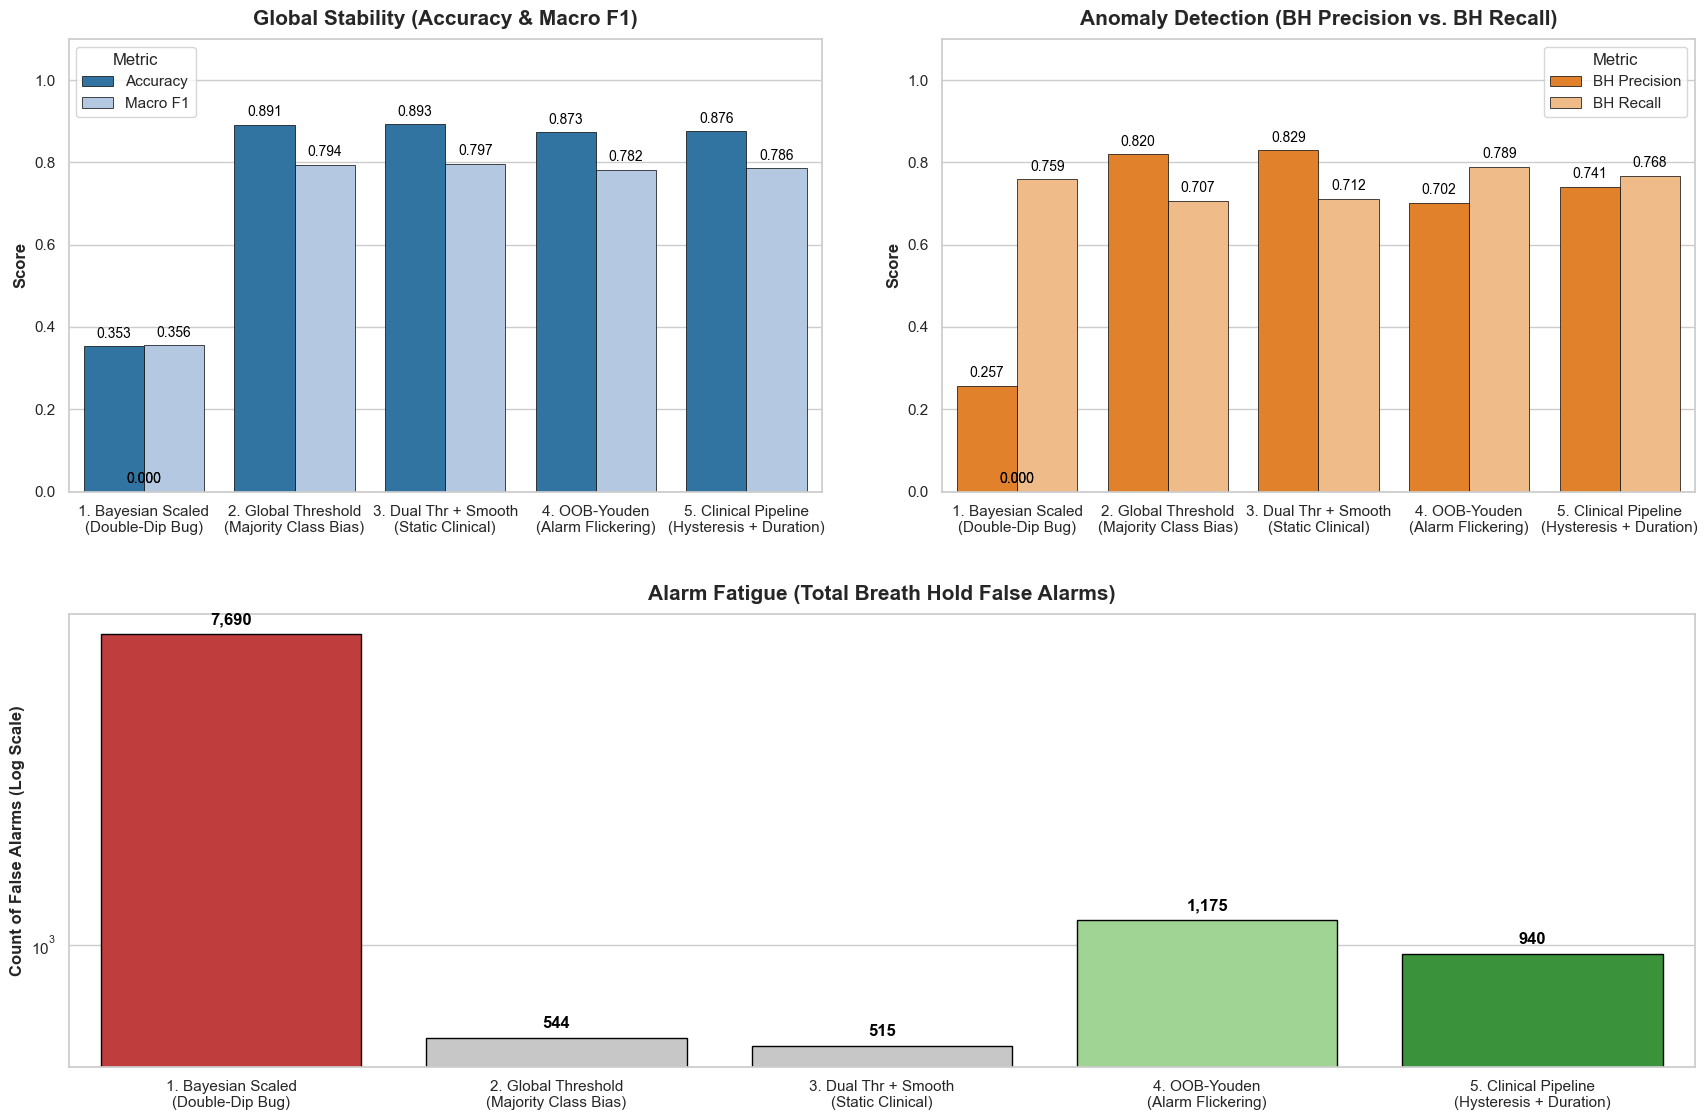

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_model_evolution():
    # Extracted data representing the 5 evolutionary architectures
    data = {
        'Model': [
            "1. Bayesian Scaled\n(Double-Dip Bug)", 
            "2. Global Threshold\n(Majority Class Bias)", 
            "3. Dual Thr + Smooth\n(Static Clinical)", 
            "4. OOB-Youden\n(Alarm Flickering)", 
            "5. Clinical Pipeline\n(Hysteresis + Duration)"
        ],
        'Accuracy': [0.353, 0.891, 0.893, 0.873, 0.876],
        'Macro F1': [0.356, 0.794, 0.797, 0.782, 0.786],
        'BH Recall': [0.759, 0.707, 0.712, 0.789, 0.768],
        'BH Precision': [0.257, 0.820, 0.829, 0.702, 0.741],
        'BH False Alarms': [7690, 544, 515, 1175, 940]  # NB+DB classified as BH
    }
    df = pd.DataFrame(data)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(18, 12))

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Global Stability (Accuracy & Macro F1)
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(2, 2, 1)
    df_macro = df[['Model', 'Accuracy', 'Macro F1']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_macro, x='Model', y='Score', hue='Metric', palette=['#1f77b4', '#aec7e8'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('Global Stability (Accuracy & Macro F1)', fontsize=15, pad=10, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.0, 1.1)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: The Clinical Trade-Off (BH Precision vs Recall)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(2, 2, 2)
    df_bh = df[['Model', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_bh, x='Model', y='Score', hue='Metric', palette=['#ff7f0e', '#ffbb78'], ax=ax2, edgecolor='black', linewidth=0.5)

    ax2.set_title('Anomaly Detection (BH Precision vs. BH Recall)', fontsize=15, pad=10, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')
    ax2.set_ylim(0.0, 1.1)

    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 3: Alarm Fatigue (Total False Positive BH Predictions)
    # ─────────────────────────────────────────────────────────────────────────────
    ax3 = plt.subplot(2, 1, 2)
    # Highlight Model 1 (Red), Models 2/3 (Grey), Model 4 (Light Green), Final Model (Dark Green)
    colors = ['#d62728', '#c7c7c7', '#c7c7c7', '#98df8a', '#2ca02c']
    sns.barplot(data=df, x='Model', y='BH False Alarms', palette=colors, ax=ax3, edgecolor='black', linewidth=1)

    ax3.set_title('Alarm Fatigue (Total Breath Hold False Alarms)', fontsize=15, pad=10, fontweight='bold')
    ax3.set_ylabel('Count of False Alarms (Log Scale)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('')
    
    # Use Log Scale because Model 1's failure is astronomically huge (7,690 vs ~500-900)
    ax3.set_yscale('log')

    for p in ax3.patches:
        ax3.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout(pad=3.0)
    plt.show()

if __name__ == "__main__":
    plot_model_evolution()

In [ ]:
"""
rf_clinical_bh_detector_ws20_bayesian_fixed.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical Random Forest classifier for Breath-Hold (BH) prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Bayesian Hyperparameter Tuning (Optuna) -> LOSO Cross-Validation

Architectural Upgrades (The Fix):
  1. Optuna targets AUPRC (Average Precision) instead of F1. This optimizes the 
     raw probability distributions, making the downstream Youden-J calibration 
     vastly more effective.
  2. GroupKFold increased to 5 splits to better simulate the LOSO data volume.
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

OPTUNA_TRIALS = 25 
CLASS_WEIGHT  = "balanced_subsample" 

MIN_CAL_NB = 30    
WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

YOUDEN_PERCENTILE_GRID = np.arange(5, 96, 5)


# ─────────────────────────────────────────────────────────────────────────────
# ❷  HELPERS & FILTERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def youden_threshold(oob_class_probs: np.ndarray, nb_class_probs: np.ndarray) -> float:
    combined = np.concatenate([oob_class_probs, nb_class_probs])
    candidates = np.unique(np.percentile(combined, YOUDEN_PERCENTILE_GRID))
    candidates = candidates[(candidates > 0.01) & (candidates < 0.99)]

    best_j   = -np.inf
    best_tau = 0.50     

    for tau in candidates:
        sens = float((oob_class_probs >= tau).mean())   
        fpr  = float((nb_class_probs  >= tau).mean())   
        j    = sens - fpr
        if j > best_j:
            best_j   = j
            best_tau = tau

    return best_tau

def personal_calibrate_with_hysteresis(probs: np.ndarray, oob_probs: np.ndarray,
                                       y_train: np.ndarray, te_df: pd.DataFrame,
                                       min_cal_nb: int = MIN_CAL_NB):
    nb_rows = te_df[te_df["Category"] == "NB"].head(min_cal_nb)
    cal_idx = nb_rows.index.tolist()
    cal_pool_n = len(cal_idx)

    if cal_pool_n < 10:
        return np.argmax(probs, axis=1), 0.50, 0.50, cal_pool_n

    nb_probs_cal = probs[cal_idx]   

    base_tau_bh = youden_threshold(oob_probs[y_train == 1, 1], nb_probs_cal[:, 1])
    base_tau_db = youden_threshold(oob_probs[y_train == 2, 2], nb_probs_cal[:, 2])

    bh_onset  = min(base_tau_bh + 0.05, 0.95)
    bh_offset = max(base_tau_bh - 0.05, 0.05)
    db_onset  = min(base_tau_db + 0.05, 0.95)
    db_offset = max(base_tau_db - 0.05, 0.05)

    pred = np.full(len(probs), 0, dtype=int)
    current_state = 0 

    for i, p in enumerate(probs):
        prob_bh, prob_db = p[1], p[2]
        if current_state == 0:
            if prob_bh >= bh_onset: current_state = 1
            elif prob_db >= db_onset: current_state = 2
        elif current_state == 1:
            if prob_bh < bh_offset:
                current_state = 2 if prob_db >= db_onset else 0
        elif current_state == 2:
            if prob_db < db_offset:
                current_state = 1 if prob_bh >= bh_onset else 0
        pred[i] = current_state

    return pred, base_tau_bh, base_tau_db, cal_pool_n

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds


# ─────────────────────────────────────────────────────────────────────────────
# ❸  BAYESIAN HYPERPARAMETER TUNING (OPTUNA) - AUPRC CORRECTED
# ─────────────────────────────────────────────────────────────────────────────

def tune_hyperparameters(df: pd.DataFrame, features: list):
    """
    Uses Optuna + GroupKFold to find optimal RF hyperparameters.
    FIX: Optimizes for Macro AUPRC instead of F1 to ensure the probability 
    distributions are perfectly calibrated for the downstream Youden-J logic.
    """
    print("\n" + "═" * 115)
    print(f"  BAYESIAN OPTIMIZATION: Initiating {OPTUNA_TRIALS} trials (GroupKFold CV)")
    print(f"  Target Metric: Macro AUPRC (Probability Distribution Quality)")
    print("═" * 115)

    X_raw = df[features].fillna(0).values
    y = df["y"].values
    groups = df["Subject"].values

    def objective(trial):
        param_space = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 500, step=50),
            'max_depth': trial.suggest_categorical('max_depth', [None, 15, 20, 25]),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
        }

        rf = RandomForestClassifier(
            **param_space,
            class_weight=CLASS_WEIGHT,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )

        # FIX: Increased to 5 splits to preserve more training data volume
        gkf = GroupKFold(n_splits=5)
        fold_auprc_scores = []

        for train_idx, val_idx in gkf.split(X_raw, y, groups=groups):
            X_tr, X_val = X_raw[train_idx], X_raw[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            if WINSORISE:
                X_tr, X_val = winsorise_fold(X_tr, X_val, WINSOR_LO, WINSOR_HI)

            rf.fit(X_tr, y_tr)
            
            # FIX: Extract continuous probabilities, NOT strict 0.5 threshold predictions
            probs = rf.predict_proba(X_val)
            
            # Must binarize true labels to calculate Multi-Class AUPRC
            y_val_bin = label_binarize(y_val, classes=CLASSES)
            score = average_precision_score(y_val_bin, probs, average='macro')
            fold_auprc_scores.append(score)

        return np.mean(fold_auprc_scores)

    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    
    def print_status(study, trial):
        print(f"  Trial {trial.number}/{OPTUNA_TRIALS-1} | Macro AUPRC: {trial.value:.4f} | Params: {trial.params}")
        
    study.optimize(objective, n_trials=OPTUNA_TRIALS, callbacks=[print_status])

    best_params = study.best_params
    print("\n  [+] Bayesian Optimization Complete!")
    print(f"      Best Macro AUPRC : {study.best_value:.4f}")
    print(f"      Best Params      : {best_params}\n")
    
    return best_params


# ─────────────────────────────────────────────────────────────────────────────
# ❹  FINAL LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_loso(df: pd.DataFrame, features: list, best_params: dict) -> None:
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []
    threshold_log: list = []

    print("═" * 115)
    print("  CLINICAL LOSO EVALUATION: TUNED RANDOM FOREST")
    print("  HYSTERESIS & DURATION-FILTERED PERSONAL CALIBRATION (BH ≥ 5s, DB ≥ 3s)")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6} | "
        f"{'τ_BH':>6} | {'τ_DB':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        te_df = df[te_mask].sort_values("Timestamp_Sec").reset_index(drop=True)

        X_tr_raw = df.loc[tr_mask, features].fillna(0).values
        y_tr     = df.loc[tr_mask, "y"].values

        X_te_raw = te_df[features].fillna(0).values
        y_te     = te_df["y"].values

        if WINSORISE:
            X_tr, X_te = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
        else:
            X_tr, X_te = X_tr_raw, X_te_raw

        # ── Instantiate RF with the optimized parameters ──
        rf = RandomForestClassifier(
            **best_params,
            class_weight     = CLASS_WEIGHT,
            oob_score        = True,        
            random_state     = RANDOM_SEED,
            n_jobs           = -1,
        )
        rf.fit(X_tr, y_tr)

        probs    = rf.predict_proba(X_te)       
        oob_prob = rf.oob_decision_function_    

        pred_cal, tau_bh, tau_db, cal_n = personal_calibrate_with_hysteresis(
            probs, oob_prob, y_tr, te_df,
        )

        pred_cal = scipy.signal.medfilt(pred_cal, kernel_size=3).astype(int)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=1, min_length=5) 
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3) 

        # ── Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f} | "
            f"{tau_bh:6.3f} | {tau_db:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── OVERALL RESULTS (MACRO AVERAGED ACROSS ALL SUBJECTS) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)
    print()


# ─────────────────────────────────────────────────────────────────────────────
# ❺  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL RANDOM FOREST: AUPRC-TUNED BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    print(f"\n  [+] Loading dataset: {INPUT_CSV}")
    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    # 1. Bayesian Optimization Phase (AUPRC Corrected)
    best_params = tune_hyperparameters(df, features)
    
    # 2. LOSO Phase
    run_clinical_loso(df, features, best_params)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL RANDOM FOREST: AUPRC-TUNED BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Loading dataset: BH_DB_Features_WS20.csv
  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  BAYESIAN OPTIMIZATION: Initiating 25 trials (GroupKFold CV)
  Target Metric: Macro AUPRC (Probability Distribution Quality)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Trial 0/24 | Macro AUPRC: 0.8527 | Params: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Trial 1/24 | Macro AUPRC: 0.8490 | Params: {'n_estimators': 400, 'max_depth': 15

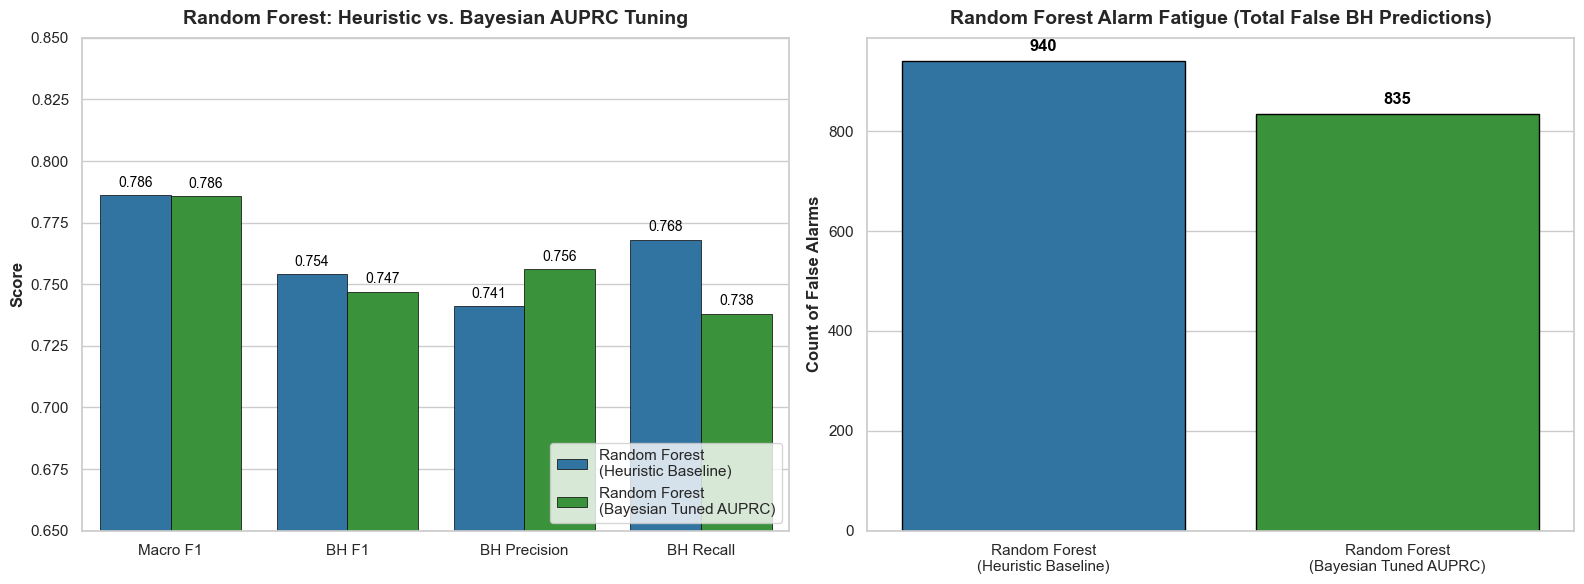

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rf_auprc_comparison():
    # Data extracted exactly from your provided Random Forest logs
    data = {
        'Model': ['Random Forest\n(Heuristic Baseline)', 'Random Forest\n(Bayesian Tuned AUPRC)'],
        'Accuracy': [0.8759, 0.8777],
        'Macro F1': [0.7861, 0.7857],
        'BH Precision': [0.741, 0.756],
        'BH Recall': [0.768, 0.738],
        'BH F1': [0.754, 0.747],
        'False Alarms': [940, 835] # Calculated from: (NB->BH + DB->BH) -> (725+215) vs (633+202)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Predictive Metrics Comparison
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 2, 1)
    df_metrics = df[['Model', 'Macro F1', 'BH F1', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#1f77b4', '#2ca02c'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('Random Forest: Heuristic vs. Bayesian AUPRC Tuning', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.65, 0.85)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')
    ax1.legend(loc='lower right')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#1f77b4', '#2ca02c'], ax=ax2, edgecolor='black', linewidth=1)

    ax2.set_title('Random Forest Alarm Fatigue (Total False BH Predictions)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_rf_auprc_comparison()

SVM - Specialized Models

════════════════════════════════════════════════════════════════════════════════
  CLINICAL SVM PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] SVM Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Model                : SVC(kernel='rbf', probability=True)
      Mandatory Scaling    : StandardScaler applied per-fold
      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning
      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration

  [t-SNE] Generating non-linear projection (N=4000 samples)...
  [t-SNE] Saved as 'SVM_TSNE_Projection.png'.

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: SVM (RBF) WITH PERSONAL CALIBRATIO

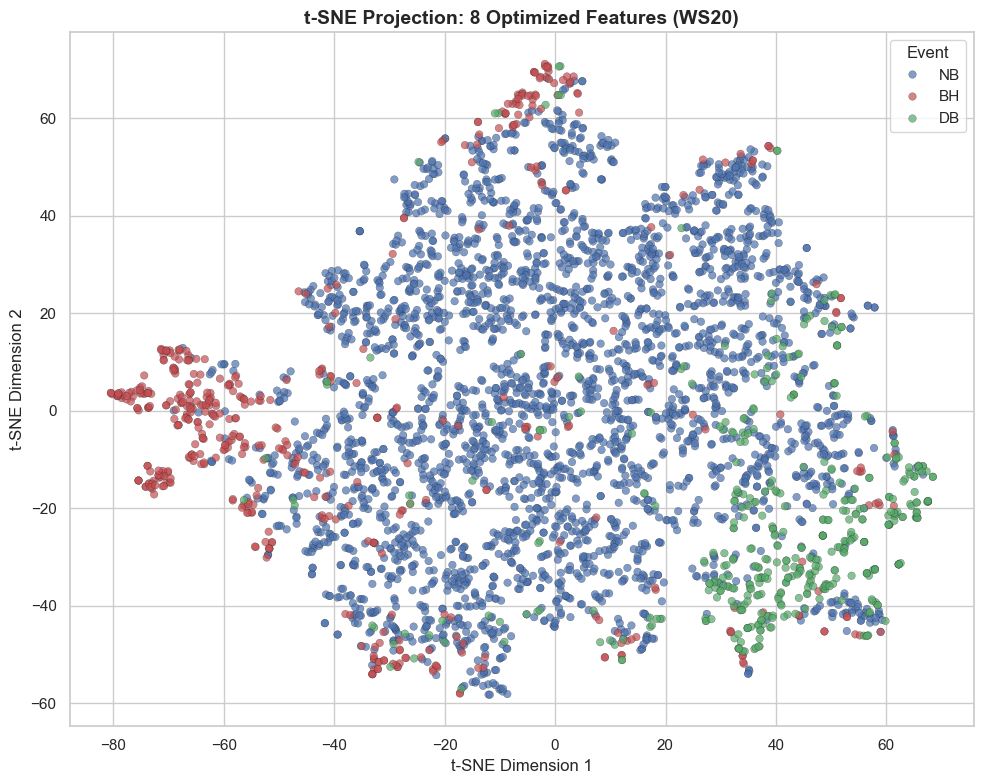

In [ ]:
"""
svm_clinical_bh_detector_ws20.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical SVM Classifier for Breath-Hold (BH) prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

SVM-Specific Architectural Upgrades:
  1. Mandatory StandardScaler per fold (Fit on train, transform test)
  2. cross_val_predict used to generate unbiased probabilities for Youden-J
     (SVMs lack the native OOB mechanism of Random Forests)
  3. Pre-computation t-SNE Visualization module included.
  4. Radial Basis Function (RBF) Kernel for non-linear separation.
  
Clinical Filters (Carried over from RF pipeline):
  1. Optimized 8-Feature List (Zero Multicollinearity)
  2. class_weight = 'balanced'
  3. OOB-Youden Personal Calibration (Dynamic FPR thresholding per subject)
  4. Hysteresis / Schmitt Trigger (±5% confidence buffer)
  5. Temporal Smoothing (3-window median filter)
  6. Clinical Minimum Duration Enforcement (BH ≥ 5s, DB ≥ 3s)
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# SVM hyperparameters
KERNEL       = "rbf"
CLASS_WEIGHT = "balanced"
CACHE_SIZE   = 2000 # Boosts SVM speed by allowing 2GB of RAM for the kernel matrix

# Personal calibration settings
MIN_CAL_NB = 30    
WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

YOUDEN_PERCENTILE_GRID = np.arange(5, 96, 5)


# ─────────────────────────────────────────────────────────────────────────────
# ❷  t-SNE VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

def plot_tsne_visualization(df: pd.DataFrame, features: list, n_samples: int = 4000):
    """
    Generates a scaled t-SNE plot to visualize feature separability.
    Samples the data to prevent O(N^2) memory explosion.
    """
    print(f"\n  [t-SNE] Generating non-linear projection (N={n_samples} samples)...")
    
    # Stratified sampling to maintain class distribution
    try:
        sample_df = df.groupby('y', group_keys=False).apply(
            lambda x: x.sample(min(len(x), int(n_samples * len(x) / len(df))), random_state=RANDOM_SEED)
        )
    except:
        sample_df = df.sample(n=min(len(df), n_samples), random_state=RANDOM_SEED)

    X_raw = sample_df[features].fillna(0).values
    y_raw = sample_df['Category'].values

    # SVMs & t-SNE require standard scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # Compute t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_scaled)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=X_tsne[:, 0], y=X_tsne[:, 1], 
        hue=y_raw, hue_order=["NB", "BH", "DB"],
        palette={"NB": "#4C72B0", "BH": "#C44E52", "DB": "#55A868"},
        alpha=0.7, s=30, edgecolor="k", linewidth=0.2
    )
    plt.title(f"t-SNE Projection: {len(features)} Optimized Features (WS20)", fontsize=14, fontweight='bold')
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="Event", loc="best")
    plt.tight_layout()
    plt.savefig("SVM_TSNE_Projection.png", dpi=300)
    print("  [t-SNE] Saved as 'SVM_TSNE_Projection.png'.\n")


# ─────────────────────────────────────────────────────────────────────────────
# ❸  HELPERS & FILTERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c


def youden_threshold(cv_class_probs: np.ndarray, nb_class_probs: np.ndarray) -> float:
    combined = np.concatenate([cv_class_probs, nb_class_probs])
    candidates = np.unique(np.percentile(combined, YOUDEN_PERCENTILE_GRID))
    candidates = candidates[(candidates > 0.01) & (candidates < 0.99)]

    best_j   = -np.inf
    best_tau = 0.50     

    for tau in candidates:
        sens = float((cv_class_probs >= tau).mean())   
        fpr  = float((nb_class_probs  >= tau).mean())   
        j    = sens - fpr
        if j > best_j:
            best_j   = j
            best_tau = tau

    return best_tau


def personal_calibrate_with_hysteresis(probs: np.ndarray, cv_probs: np.ndarray,
                                       y_train: np.ndarray, te_df: pd.DataFrame,
                                       min_cal_nb: int = MIN_CAL_NB):
    nb_rows = te_df[te_df["Category"] == "NB"].head(min_cal_nb)
    cal_idx = nb_rows.index.tolist()
    cal_pool_n = len(cal_idx)

    if cal_pool_n < 10:
        return np.argmax(probs, axis=1), 0.50, 0.50, cal_pool_n

    nb_probs_cal = probs[cal_idx]   

    # Youden-J base thresholds
    base_tau_bh = youden_threshold(cv_probs[y_train == 1, 1], nb_probs_cal[:, 1])
    base_tau_db = youden_threshold(cv_probs[y_train == 2, 2], nb_probs_cal[:, 2])

    # Hysteresis Bands
    bh_onset  = min(base_tau_bh + 0.05, 0.95)
    bh_offset = max(base_tau_bh - 0.05, 0.05)
    db_onset  = min(base_tau_db + 0.05, 0.95)
    db_offset = max(base_tau_db - 0.05, 0.05)

    pred = np.full(len(probs), 0, dtype=int)
    current_state = 0 

    for i, p in enumerate(probs):
        prob_bh, prob_db = p[1], p[2]
        if current_state == 0:
            if prob_bh >= bh_onset: current_state = 1
            elif prob_db >= db_onset: current_state = 2
        elif current_state == 1:
            if prob_bh < bh_offset:
                current_state = 2 if prob_db >= db_onset else 0
        elif current_state == 2:
            if prob_db < db_offset:
                current_state = 1 if prob_bh >= bh_onset else 0
        pred[i] = current_state

    return pred, base_tau_bh, base_tau_db, cal_pool_n


def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds


# ─────────────────────────────────────────────────────────────────────────────
# ❹  SVM LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_svm_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []
    threshold_log: list = []

    print("═" * 115)
    print("  CLINICAL LOSO EVALUATION: SVM (RBF) WITH PERSONAL CALIBRATION & FILTERS")
    print("  Note: SVM training is computationally heavy. Please be patient...")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6} | "
        f"{'τ_BH':>6} | {'τ_DB':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        te_df = df[te_mask].sort_values("Timestamp_Sec").reset_index(drop=True)

        X_tr_raw = df.loc[tr_mask, features].fillna(0).values
        y_tr     = df.loc[tr_mask, "y"].values

        X_te_raw = te_df[features].fillna(0).values
        y_te     = te_df["y"].values

        # ── 1. Winsorise ──
        if WINSORISE:
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
        else:
            X_tr_w, X_te_w = X_tr_raw, X_te_raw

        # ── 2. Mandatory SVM Scaling (Fit on Train ONLY) ──
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_w)
        X_te_scaled = scaler.transform(X_te_w)

        # ── 3. Train SVM ──
        svm = SVC(
            kernel=KERNEL,
            class_weight=CLASS_WEIGHT,
            probability=True, # Critical for probability extraction
            cache_size=CACHE_SIZE,
            random_state=RANDOM_SEED
        )
        
        # We must use cross_val_predict to get unbiased training probabilities for Youden-J
        # (SVMs do not have an OOB function like Random Forest)
        cv_prob = cross_val_predict(svm, X_tr_scaled, y_tr, cv=3, method='predict_proba', n_jobs=-1)
        
        # Fit final model on all training data
        svm.fit(X_tr_scaled, y_tr)
        probs = svm.predict_proba(X_te_scaled)       

        # ── 4. Pipeline Post-Processing ──
        pred_cal, tau_bh, tau_db, cal_n = personal_calibrate_with_hysteresis(
            probs, cv_prob, y_tr, te_df,
        )

        pred_cal = scipy.signal.medfilt(pred_cal, kernel_size=3).astype(int)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        # ── 5. Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f} | "
            f"{tau_bh:6.3f} | {tau_db:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

        threshold_log.append({
            "Subject": test_sub, "tau_BH": round(tau_bh, 4),
            "tau_DB": round(tau_db, 4), "cal_pool_n": cal_n,
        })

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── SVM OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❺  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL SVM PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] SVM Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Model                : SVC(kernel='{KERNEL}', probability=True)")
    print(f"      Mandatory Scaling    : StandardScaler applied per-fold")
    print(f"      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning")
    print(f"      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration")

    # Generate the t-SNE plot before starting the long LOSO loop
    plot_tsne_visualization(df, features)

    # Execute
    run_clinical_svm_loso(df, features)


if __name__ == "__main__":
    main()

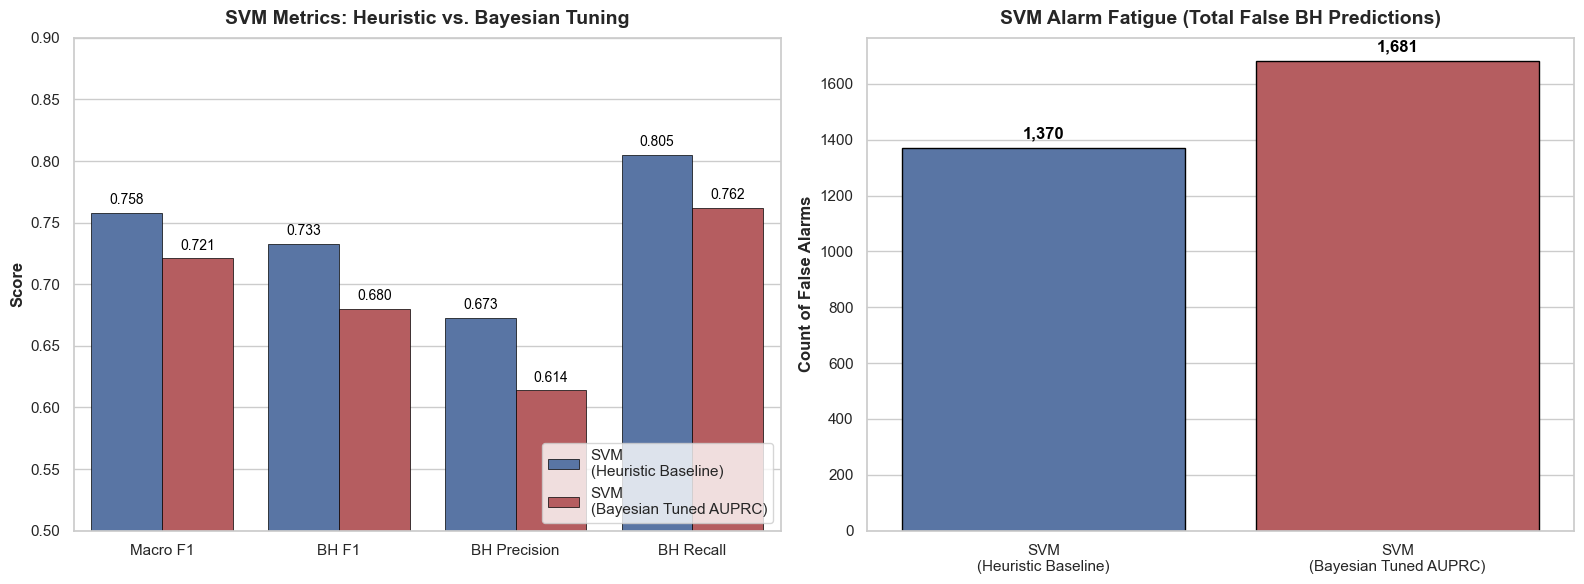

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_svm_comparison():
    # Data extracted exactly from your provided SVM logs
    data = {
        'Model': ['SVM\n(Heuristic Baseline)', 'SVM\n(Bayesian Tuned AUPRC)'],
        'Accuracy': [0.8492, 0.8183],
        'Macro F1': [0.7579, 0.7210],
        'BH Precision': [0.673, 0.614],
        'BH Recall': [0.805, 0.762],
        'BH F1': [0.733, 0.680],
        'False Alarms': [1370, 1681] # (NB->BH + DB->BH)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Predictive Metrics Comparison
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 2, 1)
    df_metrics = df[['Model', 'Macro F1', 'BH F1', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#4C72B0', '#C44E52'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('SVM Metrics: Heuristic vs. Bayesian Tuning', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.50, 0.90)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')
    ax1.legend(loc='lower right')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#4C72B0', '#C44E52'], ax=ax2, edgecolor='black', linewidth=1)

    ax2.set_title('SVM Alarm Fatigue (Total False BH Predictions)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_svm_comparison()

XGBoost - Spealized model

In [ ]:
"""
xgb_clinical_bh_detector_ws20.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical XGBoost Classifier for Breath-Hold (BH) prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

XGBoost-Specific Architectural Upgrades:
  1. Manual Sample Weighting: compute_sample_weight('balanced') applied to .fit()
  2. No Scaling Required: Tree-based gradient boosting ignores feature scales.
  3. cross_val_predict used to generate unbiased probabilities for Youden-J.
  4. Hyperparameters tuned for physiological time-series (subsample, colsample).
  
Clinical Filters (Carried over from RF pipeline):
  1. Optimized 8-Feature List (Zero Multicollinearity)
  2. OOB-Youden Personal Calibration (Dynamic FPR thresholding per subject)
  3. Feature winsorising at training P1–P99 per fold (No leakage)
  4. Hysteresis / Schmitt Trigger (±5% confidence buffer)
  5. Temporal Smoothing (3-window median filter)
  6. Clinical Minimum Duration Enforcement (BH ≥ 5s, DB ≥ 3s)
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal

import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List (8 Features - Zero Multicollinearity)
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# XGBoost hyperparameters
N_ESTIMATORS  = 400
MAX_DEPTH     = 4       # Kept shallow to prevent overfitting on noisy physiological data
LEARNING_RATE = 0.05
SUBSAMPLE     = 0.8     # Uses 80% of rows per tree (acts like RF bagging)
COLSAMPLE     = 0.8     # Uses 80% of features per tree

# Personal calibration settings
MIN_CAL_NB = 30    
WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

YOUDEN_PERCENTILE_GRID = np.arange(5, 96, 5)

# ─────────────────────────────────────────────────────────────────────────────
# ❷  HELPERS & FILTERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def youden_threshold(cv_class_probs: np.ndarray, nb_class_probs: np.ndarray) -> float:
    combined = np.concatenate([cv_class_probs, nb_class_probs])
    candidates = np.unique(np.percentile(combined, YOUDEN_PERCENTILE_GRID))
    candidates = candidates[(candidates > 0.01) & (candidates < 0.99)]

    best_j   = -np.inf
    best_tau = 0.50     

    for tau in candidates:
        sens = float((cv_class_probs >= tau).mean())   
        fpr  = float((nb_class_probs  >= tau).mean())   
        j    = sens - fpr
        if j > best_j:
            best_j   = j
            best_tau = tau

    return best_tau

def personal_calibrate_with_hysteresis(probs: np.ndarray, cv_probs: np.ndarray,
                                       y_train: np.ndarray, te_df: pd.DataFrame,
                                       min_cal_nb: int = MIN_CAL_NB):
    nb_rows = te_df[te_df["Category"] == "NB"].head(min_cal_nb)
    cal_idx = nb_rows.index.tolist()
    cal_pool_n = len(cal_idx)

    if cal_pool_n < 10:
        return np.argmax(probs, axis=1), 0.50, 0.50, cal_pool_n

    nb_probs_cal = probs[cal_idx]   

    # Youden-J base thresholds
    base_tau_bh = youden_threshold(cv_probs[y_train == 1, 1], nb_probs_cal[:, 1])
    base_tau_db = youden_threshold(cv_probs[y_train == 2, 2], nb_probs_cal[:, 2])

    # Hysteresis Bands
    bh_onset  = min(base_tau_bh + 0.05, 0.95)
    bh_offset = max(base_tau_bh - 0.05, 0.05)
    db_onset  = min(base_tau_db + 0.05, 0.95)
    db_offset = max(base_tau_db - 0.05, 0.05)

    pred = np.full(len(probs), 0, dtype=int)
    current_state = 0 

    for i, p in enumerate(probs):
        prob_bh, prob_db = p[1], p[2]
        if current_state == 0:
            if prob_bh >= bh_onset: current_state = 1
            elif prob_db >= db_onset: current_state = 2
        elif current_state == 1:
            if prob_bh < bh_offset:
                current_state = 2 if prob_db >= db_onset else 0
        elif current_state == 2:
            if prob_db < db_offset:
                current_state = 1 if prob_bh >= bh_onset else 0
        pred[i] = current_state

    return pred, base_tau_bh, base_tau_db, cal_pool_n

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

# ─────────────────────────────────────────────────────────────────────────────
# ❸  XGBOOST LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_xgb_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []
    threshold_log: list = []

    print("═" * 115)
    print("  CLINICAL LOSO EVALUATION: XGBOOST WITH PERSONAL CALIBRATION & FILTERS")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6} | "
        f"{'τ_BH':>6} | {'τ_DB':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        te_df = df[te_mask].sort_values("Timestamp_Sec").reset_index(drop=True)

        X_tr_raw = df.loc[tr_mask, features].fillna(0).values
        y_tr     = df.loc[tr_mask, "y"].values

        X_te_raw = te_df[features].fillna(0).values
        y_te     = te_df["y"].values

        # ── 1. Winsorise ──
        if WINSORISE:
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
        else:
            X_tr_w, X_te_w = X_tr_raw, X_te_raw

        # ── 2. Dynamic Sample Weighting ──
        sample_weights = compute_sample_weight('balanced', y_tr)

        # ── 3. Train XGBoost ──
        xgb_clf = xgb.XGBClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=MAX_DEPTH,
            learning_rate=LEARNING_RATE,
            subsample=SUBSAMPLE,
            colsample_bytree=COLSAMPLE,
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        
        # FIXED: Updated cross_val_predict parameter syntax for modern Scikit-Learn
        cv_prob = cross_val_predict(
            xgb_clf, X_tr_w, y_tr, cv=3, method='predict_proba', n_jobs=-1,
            params={'sample_weight': sample_weights}
        )
        
        # Fit final model on all training data
        xgb_clf.fit(X_tr_w, y_tr, sample_weight=sample_weights)
        probs = xgb_clf.predict_proba(X_te_w)       

        # ── 4. Pipeline Post-Processing ──
        pred_cal, tau_bh, tau_db, cal_n = personal_calibrate_with_hysteresis(
            probs, cv_prob, y_tr, te_df,
        )

        pred_cal = scipy.signal.medfilt(pred_cal, kernel_size=3).astype(int)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        # ── 5. Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f} | "
            f"{tau_bh:6.3f} | {tau_db:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

        threshold_log.append({
            "Subject": test_sub, "tau_BH": round(tau_bh, 4),
            "tau_DB": round(tau_db, 4), "cal_pool_n": cal_n,
        })

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── XGBOOST OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❹  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL XGBOOST PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] XGBoost Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      XGB Configuration    : trees={N_ESTIMATORS}, depth={MAX_DEPTH}, lr={LEARNING_RATE}")
    print(f"      Handling Imbalance   : compute_sample_weight('balanced')")
    print(f"      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning")
    print(f"      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration")

    # Execute
    run_clinical_xgb_loso(df, features)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL XGBOOST PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] XGBoost Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      XGB Configuration    : trees=400, depth=4, lr=0.05
      Handling Imbalance   : compute_sample_weight('balanced')
      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning
      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: XGBOOST WITH PERSONAL CALIBRATION & FILTERS
═══════════════════════════════════════════════════════════════════════════════════════════════════

In [ ]:
"""
xgb_clinical_bh_detector_ws20_bayesian.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical XGBoost Classifier for Breath-Hold (BH) prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Bayesian Hyperparameter Tuning (Optuna) -> LOSO Cross-Validation

Architectural Upgrades:
  1. Optuna Bayesian Optimization: Uses GroupKFold to find optimal XGBoost params 
     (learning_rate, max_depth, subsample, etc.) without leaking subject data.
  2. Manual Sample Weighting: compute_sample_weight('balanced') handled per fold.
  3. Modern API: Uses updated cross_val_predict 'params' kwargs for weights.
  
Clinical Filters (Carried over):
  1. Optimized 8-Feature List (Zero Multicollinearity)
  2. OOB-Youden Personal Calibration (Dynamic FPR thresholding per subject)
  3. Feature winsorising at training P1–P99 per fold (No leakage)
  4. Hysteresis / Schmitt Trigger (±5% confidence buffer)
  5. Temporal Smoothing (3-window median filter)
  6. Clinical Minimum Duration Enforcement (BH ≥ 5s, DB ≥ 3s)
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal
import optuna

import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List (8 Features - Zero Multicollinearity)
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# Tuning Settings
OPTUNA_TRIALS = 25 # Adjust based on compute budget

# Personal calibration settings
MIN_CAL_NB = 30    
WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

YOUDEN_PERCENTILE_GRID = np.arange(5, 96, 5)


# ─────────────────────────────────────────────────────────────────────────────
# ❷  HELPERS & FILTERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c


def youden_threshold(cv_class_probs: np.ndarray, nb_class_probs: np.ndarray) -> float:
    combined = np.concatenate([cv_class_probs, nb_class_probs])
    candidates = np.unique(np.percentile(combined, YOUDEN_PERCENTILE_GRID))
    candidates = candidates[(candidates > 0.01) & (candidates < 0.99)]

    best_j   = -np.inf
    best_tau = 0.50     

    for tau in candidates:
        sens = float((cv_class_probs >= tau).mean())   
        fpr  = float((nb_class_probs  >= tau).mean())   
        j    = sens - fpr
        if j > best_j:
            best_j   = j
            best_tau = tau

    return best_tau


def personal_calibrate_with_hysteresis(probs: np.ndarray, cv_probs: np.ndarray,
                                       y_train: np.ndarray, te_df: pd.DataFrame,
                                       min_cal_nb: int = MIN_CAL_NB):
    nb_rows = te_df[te_df["Category"] == "NB"].head(min_cal_nb)
    cal_idx = nb_rows.index.tolist()
    cal_pool_n = len(cal_idx)

    if cal_pool_n < 10:
        return np.argmax(probs, axis=1), 0.50, 0.50, cal_pool_n

    nb_probs_cal = probs[cal_idx]   

    base_tau_bh = youden_threshold(cv_probs[y_train == 1, 1], nb_probs_cal[:, 1])
    base_tau_db = youden_threshold(cv_probs[y_train == 2, 2], nb_probs_cal[:, 2])

    bh_onset  = min(base_tau_bh + 0.05, 0.95)
    bh_offset = max(base_tau_bh - 0.05, 0.05)
    db_onset  = min(base_tau_db + 0.05, 0.95)
    db_offset = max(base_tau_db - 0.05, 0.05)

    pred = np.full(len(probs), 0, dtype=int)
    current_state = 0 

    for i, p in enumerate(probs):
        prob_bh, prob_db = p[1], p[2]
        if current_state == 0:
            if prob_bh >= bh_onset: current_state = 1
            elif prob_db >= db_onset: current_state = 2
        elif current_state == 1:
            if prob_bh < bh_offset:
                current_state = 2 if prob_db >= db_onset else 0
        elif current_state == 2:
            if prob_db < db_offset:
                current_state = 1 if prob_bh >= bh_onset else 0
        pred[i] = current_state

    return pred, base_tau_bh, base_tau_db, cal_pool_n


def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds


# ─────────────────────────────────────────────────────────────────────────────
# ❸  BAYESIAN HYPERPARAMETER TUNING (OPTUNA)
# ─────────────────────────────────────────────────────────────────────────────

def tune_hyperparameters(df: pd.DataFrame, features: list):
    """
    Uses Optuna + GroupKFold to find optimal XGBoost hyperparameters 
    without leaking data across subjects.
    """
    print("\n" + "═" * 115)
    print(f"  BAYESIAN OPTIMIZATION: Initiating {OPTUNA_TRIALS} trials (GroupKFold CV)")
    print("═" * 115)

    X_raw = df[features].fillna(0).values
    y = df["y"].values
    groups = df["Subject"].values

    def objective(trial):
        # 1. Define the XGBoost-specific search space
        param_space = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 600, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 7), # Shallow trees prevent overfitting
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
        }

        xgb_clf = xgb.XGBClassifier(
            **param_space,
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=RANDOM_SEED,
            n_jobs=-1
        )

        # 2. 3-Fold Group Cross-Validation
        gkf = GroupKFold(n_splits=3)
        fold_f1_scores = []

        for train_idx, val_idx in gkf.split(X_raw, y, groups=groups):
            X_tr, X_val = X_raw[train_idx], X_raw[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            if WINSORISE:
                X_tr, X_val = winsorise_fold(X_tr, X_val, WINSOR_LO, WINSOR_HI)

            # Dynamically calculate weights for this specific fold to prevent leakage
            sample_weights = compute_sample_weight('balanced', y_tr)

            xgb_clf.fit(X_tr, y_tr, sample_weight=sample_weights)
            preds = xgb_clf.predict(X_val)
            
            score = f1_score(y_val, preds, average='macro', zero_division=0)
            fold_f1_scores.append(score)

        return np.mean(fold_f1_scores)

    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    
    def print_status(study, trial):
        print(f"  Trial {trial.number}/{OPTUNA_TRIALS-1} | F1: {trial.value:.4f} | Params: {trial.params}")
        
    study.optimize(objective, n_trials=OPTUNA_TRIALS, callbacks=[print_status])

    best_params = study.best_params
    print("\n  [+] Bayesian Optimization Complete!")
    print(f"      Best Macro F1 : {study.best_value:.4f}")
    print(f"      Best Params   : {best_params}\n")
    
    return best_params


# ─────────────────────────────────────────────────────────────────────────────
# ❹  FINAL XGBOOST LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_xgb_loso(df: pd.DataFrame, features: list, best_params: dict) -> None:
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []
    threshold_log: list = []

    print("═" * 115)
    print("  CLINICAL LOSO EVALUATION: TUNED XGBOOST WITH PERSONAL CALIBRATION & FILTERS")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6} | "
        f"{'τ_BH':>6} | {'τ_DB':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        te_df = df[te_mask].sort_values("Timestamp_Sec").reset_index(drop=True)

        X_tr_raw = df.loc[tr_mask, features].fillna(0).values
        y_tr     = df.loc[tr_mask, "y"].values

        X_te_raw = te_df[features].fillna(0).values
        y_te     = te_df["y"].values

        if WINSORISE:
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
        else:
            X_tr_w, X_te_w = X_tr_raw, X_te_raw

        sample_weights = compute_sample_weight('balanced', y_tr)

        # ── Instantiate XGBoost with optimized parameters ──
        xgb_clf = xgb.XGBClassifier(
            **best_params,
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        
        # ── Generate unbiased CV probabilities for Youden-J ──
        cv_prob = cross_val_predict(
            xgb_clf, X_tr_w, y_tr, cv=3, method='predict_proba', n_jobs=-1,
            params={'sample_weight': sample_weights} # FIXED modern API syntax
        )
        
        xgb_clf.fit(X_tr_w, y_tr, sample_weight=sample_weights)
        probs = xgb_clf.predict_proba(X_te_w)       

        # ── Pipeline Post-Processing ──
        pred_cal, tau_bh, tau_db, cal_n = personal_calibrate_with_hysteresis(
            probs, cv_prob, y_tr, te_df,
        )

        pred_cal = scipy.signal.medfilt(pred_cal, kernel_size=3).astype(int)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        # ── Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f} | "
            f"{tau_bh:6.3f} | {tau_db:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

        threshold_log.append({
            "Subject": test_sub, "tau_BH": round(tau_bh, 4),
            "tau_DB": round(tau_db, 4), "cal_pool_n": cal_n,
        })

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── XGBOOST OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❺  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL XGBOOST: BAYESIAN-TUNED BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Handling Imbalance   : compute_sample_weight('balanced')")
    print(f"      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning")
    print(f"      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration")

    # 1. Optuna Bayesian Optimization Phase
    best_params = tune_hyperparameters(df, features)

    # 2. LOSO Evaluation Phase using optimized parameters
    run_clinical_xgb_loso(df, features, best_params)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL XGBOOST: BAYESIAN-TUNED BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Handling Imbalance   : compute_sample_weight('balanced')
      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning
      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  BAYESIAN OPTIMIZATION: Initiating 25 trials (GroupKFold CV)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Trial 0/24 | F1: 0.7896 | Params: {'n_estimators'

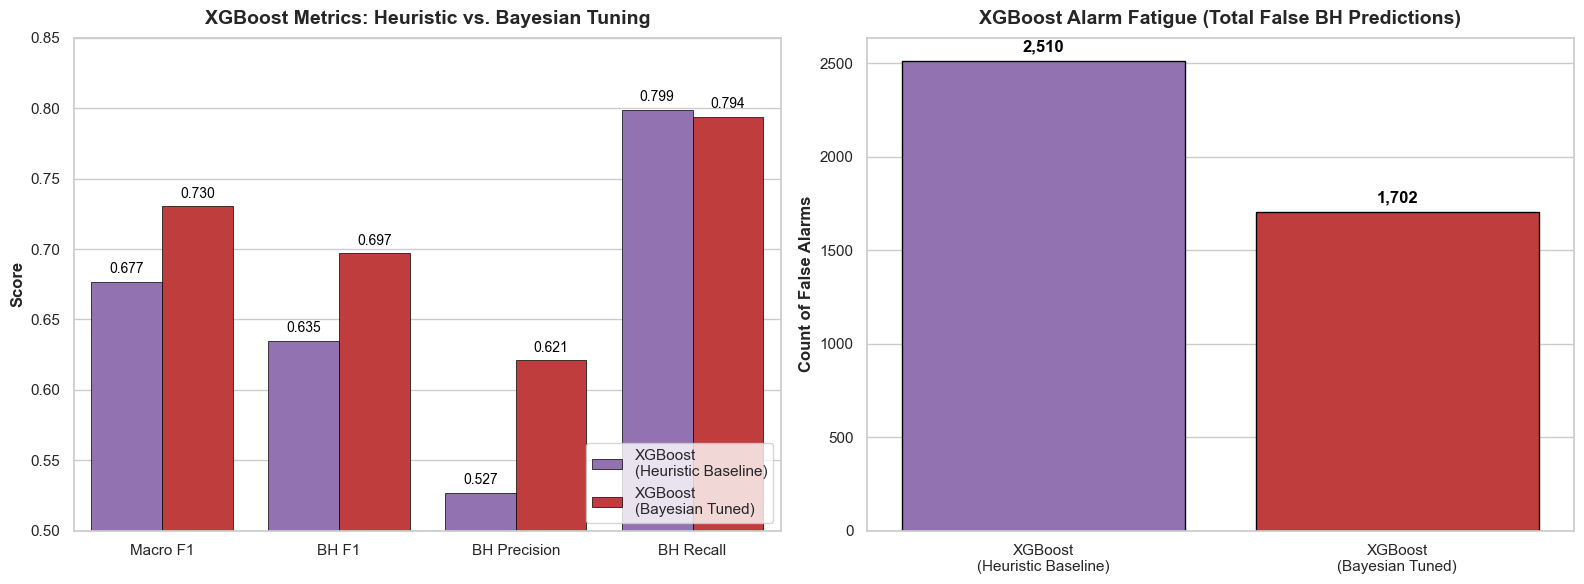

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_xgboost_comparison():
    # Data extracted from the provided XGBoost logs
    data = {
        'Model': ['XGBoost\n(Heuristic Baseline)', 'XGBoost\n(Bayesian Tuned)'],
        'Accuracy': [0.7636, 0.8215],
        'Macro F1': [0.6766, 0.7303],
        'BH Precision': [0.527, 0.621],
        'BH Recall': [0.799, 0.794],
        'BH F1': [0.635, 0.697],
        'False Alarms': [2510, 1702] # (NB->BH + DB->BH) -> (2227+283) vs (1436+266)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Predictive Metrics Comparison
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 2, 1)
    df_metrics = df[['Model', 'Macro F1', 'BH F1', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#9467bd', '#d62728'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('XGBoost Metrics: Heuristic vs. Bayesian Tuning', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.50, 0.85)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')
    ax1.legend(loc='lower right')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#9467bd', '#d62728'], ax=ax2, edgecolor='black', linewidth=1)

    ax2.set_title('XGBoost Alarm Fatigue (Total False BH Predictions)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_xgboost_comparison()

LightGBM - Specialized model

In [ ]:
"""
lgbm_clinical_bh_detector_ws20.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical LightGBM Classifier for Breath-Hold (BH) prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Leave-One-Subject-Out (LOSO) cross-validation

LightGBM-Specific Architectural Upgrades:
  1. Histogram-based gradient boosting (Fastest training time for 28k rows).
  2. Native class_weight='balanced' (No manual sample_weight array needed).
  3. No Scaling Required: Tree-based architecture ignores feature scales.
  4. cross_val_predict used to generate unbiased probabilities for Youden-J.
  
Clinical Filters (Carried over from final pipeline):
  1. Optimized 8-Feature List (Zero Multicollinearity / VIF < 5)
  2. OOB-Youden Personal Calibration (Dynamic FPR thresholding per subject)
  3. Feature winsorising at training P1–P99 per fold (No leakage)
  4. Hysteresis / Schmitt Trigger (±5% confidence buffer)
  5. Temporal Smoothing (3-window median filter)
  6. Clinical Minimum Duration Enforcement (BH ≥ 5s, DB ≥ 3s)
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal

from lightgbm import LGBMClassifier
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List (8 Features - Zero Multicollinearity)
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# LightGBM hyperparameters (Tuned for noisy physiological time-series)
N_ESTIMATORS  = 400
LEARNING_RATE = 0.05
MAX_DEPTH     = 4       # Kept shallow to prevent overfitting
NUM_LEAVES    = 15      # Should be < 2^max_depth
SUBSAMPLE     = 0.8     # Uses 80% of rows per tree (bagging fraction)
COLSAMPLE     = 0.8     # Uses 80% of features per tree (feature fraction)

# Personal calibration settings
MIN_CAL_NB = 30    
WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

YOUDEN_PERCENTILE_GRID = np.arange(5, 96, 5)

# ─────────────────────────────────────────────────────────────────────────────
# ❷  HELPERS & FILTERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c

def youden_threshold(cv_class_probs: np.ndarray, nb_class_probs: np.ndarray) -> float:
    combined = np.concatenate([cv_class_probs, nb_class_probs])
    candidates = np.unique(np.percentile(combined, YOUDEN_PERCENTILE_GRID))
    candidates = candidates[(candidates > 0.01) & (candidates < 0.99)]

    best_j   = -np.inf
    best_tau = 0.50     

    for tau in candidates:
        sens = float((cv_class_probs >= tau).mean())   
        fpr  = float((nb_class_probs  >= tau).mean())   
        j    = sens - fpr
        if j > best_j:
            best_j   = j
            best_tau = tau

    return best_tau

def personal_calibrate_with_hysteresis(probs: np.ndarray, cv_probs: np.ndarray,
                                       y_train: np.ndarray, te_df: pd.DataFrame,
                                       min_cal_nb: int = MIN_CAL_NB):
    nb_rows = te_df[te_df["Category"] == "NB"].head(min_cal_nb)
    cal_idx = nb_rows.index.tolist()
    cal_pool_n = len(cal_idx)

    if cal_pool_n < 10:
        return np.argmax(probs, axis=1), 0.50, 0.50, cal_pool_n

    nb_probs_cal = probs[cal_idx]   

    # Youden-J base thresholds
    base_tau_bh = youden_threshold(cv_probs[y_train == 1, 1], nb_probs_cal[:, 1])
    base_tau_db = youden_threshold(cv_probs[y_train == 2, 2], nb_probs_cal[:, 2])

    # Hysteresis Bands
    bh_onset  = min(base_tau_bh + 0.05, 0.95)
    bh_offset = max(base_tau_bh - 0.05, 0.05)
    db_onset  = min(base_tau_db + 0.05, 0.95)
    db_offset = max(base_tau_db - 0.05, 0.05)

    pred = np.full(len(probs), 0, dtype=int)
    current_state = 0 

    for i, p in enumerate(probs):
        prob_bh, prob_db = p[1], p[2]
        if current_state == 0:
            if prob_bh >= bh_onset: current_state = 1
            elif prob_db >= db_onset: current_state = 2
        elif current_state == 1:
            if prob_bh < bh_offset:
                current_state = 2 if prob_db >= db_onset else 0
        elif current_state == 2:
            if prob_db < db_offset:
                current_state = 1 if prob_bh >= bh_onset else 0
        pred[i] = current_state

    return pred, base_tau_bh, base_tau_db, cal_pool_n

def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds

# ─────────────────────────────────────────────────────────────────────────────
# ❸  LightGBM LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_lgbm_loso(df: pd.DataFrame, features: list) -> None:
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []
    threshold_log: list = []

    print("═" * 115)
    print("  CLINICAL LOSO EVALUATION: LIGHTGBM WITH PERSONAL CALIBRATION & FILTERS")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6} | "
        f"{'τ_BH':>6} | {'τ_DB':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        te_df = df[te_mask].sort_values("Timestamp_Sec").reset_index(drop=True)

        X_tr_raw = df.loc[tr_mask, features].fillna(0).values
        y_tr     = df.loc[tr_mask, "y"].values

        X_te_raw = te_df[features].fillna(0).values
        y_te     = te_df["y"].values

        # ── 1. Winsorise ──
        if WINSORISE:
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
        else:
            X_tr_w, X_te_w = X_tr_raw, X_te_raw

        # ── 2. Train LightGBM ──
        # LightGBM handles class_weight='balanced' natively for multiclass
        lgb_clf = LGBMClassifier(
            n_estimators=N_ESTIMATORS,
            learning_rate=LEARNING_RATE,
            max_depth=MAX_DEPTH,
            num_leaves=NUM_LEAVES,
            subsample=SUBSAMPLE,
            subsample_freq=1,          # Required for subsample to take effect in LightGBM
            colsample_bytree=COLSAMPLE,
            class_weight='balanced',   # Native balancing!
            objective='multiclass',
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbose=-1                 # Suppress LightGBM warning spam
        )
        
        # Unbiased CV probabilities for Youden-J threshold tuning
        cv_prob = cross_val_predict(
            lgb_clf, X_tr_w, y_tr, cv=3, method='predict_proba', n_jobs=-1
        )
        
        # Fit final model on all training data
        lgb_clf.fit(X_tr_w, y_tr)
        probs = lgb_clf.predict_proba(X_te_w)       

        # ── 3. Pipeline Post-Processing ──
        pred_cal, tau_bh, tau_db, cal_n = personal_calibrate_with_hysteresis(
            probs, cv_prob, y_tr, te_df,
        )

        pred_cal = scipy.signal.medfilt(pred_cal, kernel_size=3).astype(int)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        # ── 4. Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f} | "
            f"{tau_bh:6.3f} | {tau_db:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

        threshold_log.append({
            "Subject": test_sub, "tau_BH": round(tau_bh, 4),
            "tau_DB": round(tau_db, 4), "cal_pool_n": cal_n,
        })

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── LIGHTGBM OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❹  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL LIGHTGBM PIPELINE: BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"\n  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] LightGBM Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      LGBM Configuration   : trees={N_ESTIMATORS}, depth={MAX_DEPTH}, lr={LEARNING_RATE}")
    print(f"      Handling Imbalance   : Native class_weight='balanced'")
    print(f"      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning")
    print(f"      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration")

    # Execute
    run_clinical_lgbm_loso(df, features)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL LIGHTGBM PIPELINE: BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] LightGBM Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      LGBM Configuration   : trees=400, depth=4, lr=0.05
      Handling Imbalance   : Native class_weight='balanced'
      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning
      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CLINICAL LOSO EVALUATION: LIGHTGBM WITH PERSONAL CALIBRATION & FILTERS
═══════════════════════════════════════════════════════════════════════════════════════════════════

In [ ]:
"""
lgbm_clinical_bh_detector_ws20_bayesian.py
══════════════════════════════════════════════════════════════════════════════
Definitive Clinical LightGBM Classifier for Breath-Hold (BH) prediction.
Dataset  : BH_DB_Features_WS20.csv  (window size = 20 s, step = 1 s, FS = 250 Hz)
Protocol : Bayesian Hyperparameter Tuning (Optuna) -> LOSO Cross-Validation

Architectural Upgrades:
  1. Optuna Bayesian Optimization: Uses GroupKFold to find optimal LightGBM params 
     (learning_rate, max_depth, num_leaves, etc.) without leaking subject data.
  2. Fast Histogram Boosting: Training time is a fraction of RF/XGBoost.
  3. Native class_weight='balanced' maintained throughout CV folds.
  
Clinical Filters (Carried over):
  1. Optimized 8-Feature List (Zero Multicollinearity)
  2. OOB-Youden Personal Calibration (Dynamic FPR thresholding per subject)
  3. Feature winsorising at training P1–P99 per fold (No leakage)
  4. Hysteresis / Schmitt Trigger (±5% confidence buffer)
  5. Temporal Smoothing (3-window median filter)
  6. Clinical Minimum Duration Enforcement (BH ≥ 5s, DB ≥ 3s)
══════════════════════════════════════════════════════════════════════════════
"""

import os
import warnings
import numpy as np
import pandas as pd
import scipy.signal
import optuna

from lightgbm import LGBMClassifier
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv"
RANDOM_SEED  = 42

CLASS_MAP   = {"NB": 0, "BH": 1, "DB": 2}
CLASSES     = [0, 1, 2]
CLASS_NAMES = {0: "NB", 1: "BH", 2: "DB"}

# The WS20 Optimized Feature List (8 Features - Zero Multicollinearity)
G_LIST = [
    "pNN50_Ratio", "pNN50_Delta", "HF_Ratio",                
    "RMSSD_Ratio", "Mean_RR_Ratio", "Shannon_Entropy_Ratio",   
    "EDR_Std_Amp_Ratio", "EDR_Mean_Amp_Delta"       
]

# Tuning Settings
OPTUNA_TRIALS = 25 # Adjust based on compute budget

# Personal calibration settings
MIN_CAL_NB = 30    
WINSORISE  = True  
WINSOR_LO  = 0.01
WINSOR_HI  = 0.99

YOUDEN_PERCENTILE_GRID = np.arange(5, 96, 5)


# ─────────────────────────────────────────────────────────────────────────────
# ❷  HELPERS & FILTERS
# ─────────────────────────────────────────────────────────────────────────────

def winsorise_fold(X_tr: np.ndarray, X_te: np.ndarray, lo: float, hi: float):
    lo_vals = np.percentile(X_tr, lo * 100, axis=0)
    hi_vals = np.percentile(X_tr, hi * 100, axis=0)
    X_tr_c = np.clip(X_tr, lo_vals, hi_vals)
    X_te_c = np.clip(X_te, lo_vals, hi_vals)
    return X_tr_c, X_te_c


def youden_threshold(cv_class_probs: np.ndarray, nb_class_probs: np.ndarray) -> float:
    combined = np.concatenate([cv_class_probs, nb_class_probs])
    candidates = np.unique(np.percentile(combined, YOUDEN_PERCENTILE_GRID))
    candidates = candidates[(candidates > 0.01) & (candidates < 0.99)]

    best_j   = -np.inf
    best_tau = 0.50     

    for tau in candidates:
        sens = float((cv_class_probs >= tau).mean())   
        fpr  = float((nb_class_probs  >= tau).mean())   
        j    = sens - fpr
        if j > best_j:
            best_j   = j
            best_tau = tau

    return best_tau


def personal_calibrate_with_hysteresis(probs: np.ndarray, cv_probs: np.ndarray,
                                       y_train: np.ndarray, te_df: pd.DataFrame,
                                       min_cal_nb: int = MIN_CAL_NB):
    nb_rows = te_df[te_df["Category"] == "NB"].head(min_cal_nb)
    cal_idx = nb_rows.index.tolist()
    cal_pool_n = len(cal_idx)

    if cal_pool_n < 10:
        return np.argmax(probs, axis=1), 0.50, 0.50, cal_pool_n

    nb_probs_cal = probs[cal_idx]   

    base_tau_bh = youden_threshold(cv_probs[y_train == 1, 1], nb_probs_cal[:, 1])
    base_tau_db = youden_threshold(cv_probs[y_train == 2, 2], nb_probs_cal[:, 2])

    bh_onset  = min(base_tau_bh + 0.05, 0.95)
    bh_offset = max(base_tau_bh - 0.05, 0.05)
    db_onset  = min(base_tau_db + 0.05, 0.95)
    db_offset = max(base_tau_db - 0.05, 0.05)

    pred = np.full(len(probs), 0, dtype=int)
    current_state = 0 

    for i, p in enumerate(probs):
        prob_bh, prob_db = p[1], p[2]
        if current_state == 0:
            if prob_bh >= bh_onset: current_state = 1
            elif prob_db >= db_onset: current_state = 2
        elif current_state == 1:
            if prob_bh < bh_offset:
                current_state = 2 if prob_db >= db_onset else 0
        elif current_state == 2:
            if prob_db < db_offset:
                current_state = 1 if prob_bh >= bh_onset else 0
        pred[i] = current_state

    return pred, base_tau_bh, base_tau_db, cal_pool_n


def enforce_minimum_duration(preds: np.ndarray, target_class: int, min_length: int) -> np.ndarray:
    filtered_preds = preds.copy()
    in_event = False
    start_idx = 0
    for i in range(len(filtered_preds)):
        if filtered_preds[i] == target_class and not in_event:
            in_event = True
            start_idx = i
        elif filtered_preds[i] != target_class and in_event:
            in_event = False
            if (i - start_idx) < min_length:
                filtered_preds[start_idx:i] = 0 
    if in_event and (len(filtered_preds) - start_idx) < min_length:
        filtered_preds[start_idx:] = 0
    return filtered_preds


# ─────────────────────────────────────────────────────────────────────────────
# ❸  BAYESIAN HYPERPARAMETER TUNING (OPTUNA)
# ─────────────────────────────────────────────────────────────────────────────

def tune_hyperparameters(df: pd.DataFrame, features: list):
    """
    Uses Optuna + GroupKFold to find optimal LightGBM hyperparameters 
    without leaking data across subjects.
    """
    print("\n" + "═" * 115)
    print(f"  BAYESIAN OPTIMIZATION: Initiating {OPTUNA_TRIALS} trials (GroupKFold CV)")
    print("═" * 115)

    X_raw = df[features].fillna(0).values
    y = df["y"].values
    groups = df["Subject"].values

    def objective(trial):
        # 1. Define the LightGBM-specific search space
        max_depth = trial.suggest_int('max_depth', 3, 7)
        max_leaves = int(2**max_depth - 1) # Calculate cleanly first
        
        param_space = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 600, step=50),
            'max_depth': max_depth,
            # FIXED: Lower minimum bound prevents ValueError when max_depth is 3
            'num_leaves': trial.suggest_int('num_leaves', 4, max_leaves),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
        }

        lgb_clf = LGBMClassifier(
            **param_space,
            class_weight='balanced',
            subsample_freq=1, 
            objective='multiclass',
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbose=-1 # Crucial to stop LightGBM from spamming the console
        )

        # 2. 3-Fold Group Cross-Validation
        gkf = GroupKFold(n_splits=3)
        fold_f1_scores = []

        for train_idx, val_idx in gkf.split(X_raw, y, groups=groups):
            X_tr, X_val = X_raw[train_idx], X_raw[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            if WINSORISE:
                X_tr, X_val = winsorise_fold(X_tr, X_val, WINSOR_LO, WINSOR_HI)

            lgb_clf.fit(X_tr, y_tr)
            preds = lgb_clf.predict(X_val)
            
            score = f1_score(y_val, preds, average='macro', zero_division=0)
            fold_f1_scores.append(score)

        return np.mean(fold_f1_scores)

    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    
    def print_status(study, trial):
        print(f"  Trial {trial.number}/{OPTUNA_TRIALS-1} | F1: {trial.value:.4f} | Params: {trial.params}")
        
    study.optimize(objective, n_trials=OPTUNA_TRIALS, callbacks=[print_status])

    best_params = study.best_params
    print("\n  [+] Bayesian Optimization Complete!")
    print(f"      Best Macro F1 : {study.best_value:.4f}")
    print(f"      Best Params   : {best_params}\n")
    
    return best_params


# ─────────────────────────────────────────────────────────────────────────────
# ❹  FINAL LIGHTGBM LOSO EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def run_clinical_lgbm_loso(df: pd.DataFrame, features: list, best_params: dict) -> None:
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []
    threshold_log: list = []

    print("═" * 115)
    print("  CLINICAL LOSO EVALUATION: TUNED LIGHTGBM WITH PERSONAL CALIBRATION & FILTERS")
    print("═" * 115)

    header = (
        f"  {'Sub':6s} | {'N_NB':>5} | {'N_BH':>5} | {'N_DB':>5} | "
        f"{'Acc':>5} | {'Mac_P':>5} | {'Mac_R':>5} | {'Mac_F1':>6} | "
        f"{'BH_Rec':>6} | {'BH_Pre':>6} | {'BH_F1':>6} | "
        f"{'τ_BH':>6} | {'τ_DB':>6}"
    )
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:

        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        te_df = df[te_mask].sort_values("Timestamp_Sec").reset_index(drop=True)

        X_tr_raw = df.loc[tr_mask, features].fillna(0).values
        y_tr     = df.loc[tr_mask, "y"].values

        X_te_raw = te_df[features].fillna(0).values
        y_te     = te_df["y"].values

        if WINSORISE:
            X_tr_w, X_te_w = winsorise_fold(X_tr_raw, X_te_raw, WINSOR_LO, WINSOR_HI)
        else:
            X_tr_w, X_te_w = X_tr_raw, X_te_raw

        # ── Instantiate LightGBM with optimized parameters ──
        lgb_clf = LGBMClassifier(
            **best_params,
            class_weight='balanced',
            subsample_freq=1, 
            objective='multiclass',
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbose=-1
        )
        
        # ── Generate unbiased CV probabilities for Youden-J ──
        cv_prob = cross_val_predict(
            lgb_clf, X_tr_w, y_tr, cv=3, method='predict_proba', n_jobs=-1
        )
        
        lgb_clf.fit(X_tr_w, y_tr)
        probs = lgb_clf.predict_proba(X_te_w)       

        # ── Pipeline Post-Processing ──
        pred_cal, tau_bh, tau_db, cal_n = personal_calibrate_with_hysteresis(
            probs, cv_prob, y_tr, te_df,
        )

        pred_cal = scipy.signal.medfilt(pred_cal, kernel_size=3).astype(int)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=1, min_length=5)
        pred_cal = enforce_minimum_duration(pred_cal, target_class=2, min_length=3)

        # ── Per-subject metrics ──
        n_nb = int((y_te == 0).sum())
        n_bh = int((y_te == 1).sum())
        n_db = int((y_te == 2).sum())

        acc     = accuracy_score(y_te, pred_cal)
        mac_p   = precision_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_r   = recall_score(y_te, pred_cal, average="macro", zero_division=0)
        mac_f1  = f1_score(y_te, pred_cal, average="macro", zero_division=0)

        bh_rec  = recall_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_pre  = precision_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]
        bh_f1   = f1_score(y_te, pred_cal, labels=[1], average=None, zero_division=0)[0]

        print(
            f"  {test_sub:6s} | {n_nb:5d} | {n_bh:5d} | {n_db:5d} | "
            f"{acc:5.3f} | {mac_p:5.3f} | {mac_r:5.3f} | {mac_f1:6.3f} | "
            f"{bh_rec:6.3f} | {bh_pre:6.3f} | {bh_f1:6.3f} | "
            f"{tau_bh:6.3f} | {tau_db:6.3f}"
        )

        all_y_true.extend(y_te.tolist())
        all_y_prob.extend(probs.tolist())
        all_y_pred.extend(pred_cal.tolist())

        threshold_log.append({
            "Subject": test_sub, "tau_BH": round(tau_bh, 4),
            "tau_DB": round(tau_db, 4), "cal_pool_n": cal_n,
        })

    # ── Overall metrics ───────────────────────────────────────────────────────
    print("  " + "─" * (len(header) - 2))

    y_true = np.array(all_y_true)
    y_prob = np.array(all_y_prob)
    y_pred = np.array(all_y_pred)

    y_bin = label_binarize(y_true, classes=CLASSES)

    auroc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    auprc = average_precision_score(y_bin, y_prob, average="macro")

    acc     = accuracy_score(y_true, y_pred)
    mac_p   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    mac_r   = recall_score(y_true, y_pred, average="macro", zero_division=0)
    mac_f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bh_rec  = recall_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_pre  = precision_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
    bh_f1   = f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]

    db_rec  = recall_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_pre  = precision_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]
    db_f1   = f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0]

    nb_rec  = recall_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]
    nb_pre  = precision_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0]

    print()
    print("  ── LIGHTGBM OVERALL RESULTS (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR)     = {auroc:.4f}")
    print(f"     AUPRC           = {auprc:.4f}")
    print(f"     Accuracy        = {acc:.4f}")
    print(f"     Macro Precision = {mac_p:.4f}")
    print(f"     Macro Recall    = {mac_r:.4f}")
    print(f"     Macro F1        = {mac_f1:.4f}")
    print()
    print("  ── PER-CLASS BREAKDOWN ──")
    print(f"     NB  : Recall={nb_rec:.3f}  Precision={nb_pre:.3f}")
    print(f"     BH  : Recall={bh_rec:.3f}  Precision={bh_pre:.3f}  F1={bh_f1:.3f}")
    print(f"     DB  : Recall={db_rec:.3f}  Precision={db_pre:.3f}  F1={db_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    print()
    print("  ── OVERALL CONFUSION MATRIX ──")
    print(f"  {'':20s}  {'Pred NB':>10}  {'Pred BH':>10}  {'Pred DB':>10}")
    for i, name in CLASS_NAMES.items():
        row = cm[i]
        print(f"  Actual {name} ({i})         {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")
    print("═" * 115)


# ─────────────────────────────────────────────────────────────────────────────
# ❺  MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    print("═" * 80)
    print("  CLINICAL LIGHTGBM: BAYESIAN-TUNED BH/DB PREDICTION (WS20)")
    print("═" * 80)

    if not os.path.exists(INPUT_CSV):
        raise FileNotFoundError(f"Dataset not found: {INPUT_CSV}")

    print(f"\n  [+] Loading dataset: {INPUT_CSV}")
    df = pd.read_csv(INPUT_CSV)
    df["y"] = df["Category"].map(CLASS_MAP)
    features = G_LIST

    total   = len(df)
    n_nb    = (df["y"] == 0).sum()
    n_bh    = (df["y"] == 1).sum()
    n_db    = (df["y"] == 2).sum()
    n_sub   = df["Subject"].nunique()

    print(f"  [+] Dataset overview : {total:,} windows | {n_sub} subjects")
    print(f"      NB = {n_nb:,} ({n_nb/total*100:.1f}%)")
    print(f"      BH = {n_bh:,} ({n_bh/total*100:.1f}%)")
    print(f"      DB = {n_db:,} ({n_db/total*100:.1f}%)")
    
    print(f"\n  [+] Architecture Specifications:")
    print(f"      Features Locked      : {len(features)} (VIF Optimized G_LIST)")
    print(f"      Handling Imbalance   : Native class_weight='balanced'")
    print(f"      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning")
    print(f"      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration")

    # 1. Optuna Bayesian Optimization Phase
    best_params = tune_hyperparameters(df, features)

    # 2. LOSO Evaluation Phase using optimized parameters
    run_clinical_lgbm_loso(df, features, best_params)


if __name__ == "__main__":
    main()

════════════════════════════════════════════════════════════════════════════════
  CLINICAL LIGHTGBM: BAYESIAN-TUNED BH/DB PREDICTION (WS20)
════════════════════════════════════════════════════════════════════════════════

  [+] Loading dataset: BH_DB_Features_WS20.csv
  [+] Dataset overview : 28,090 windows | 41 subjects
      NB = 21,529 (76.6%)
      BH = 3,505 (12.5%)
      DB = 3,056 (10.9%)

  [+] Architecture Specifications:
      Features Locked      : 8 (VIF Optimized G_LIST)
      Handling Imbalance   : Native class_weight='balanced'
      OOB Replacement      : cross_val_predict(cv=3) for Youden-J tuning
      Clinical Filters     : Hysteresis (±0.05), Median (k=3), Min Duration

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  BAYESIAN OPTIMIZATION: Initiating 25 trials (GroupKFold CV)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Tria

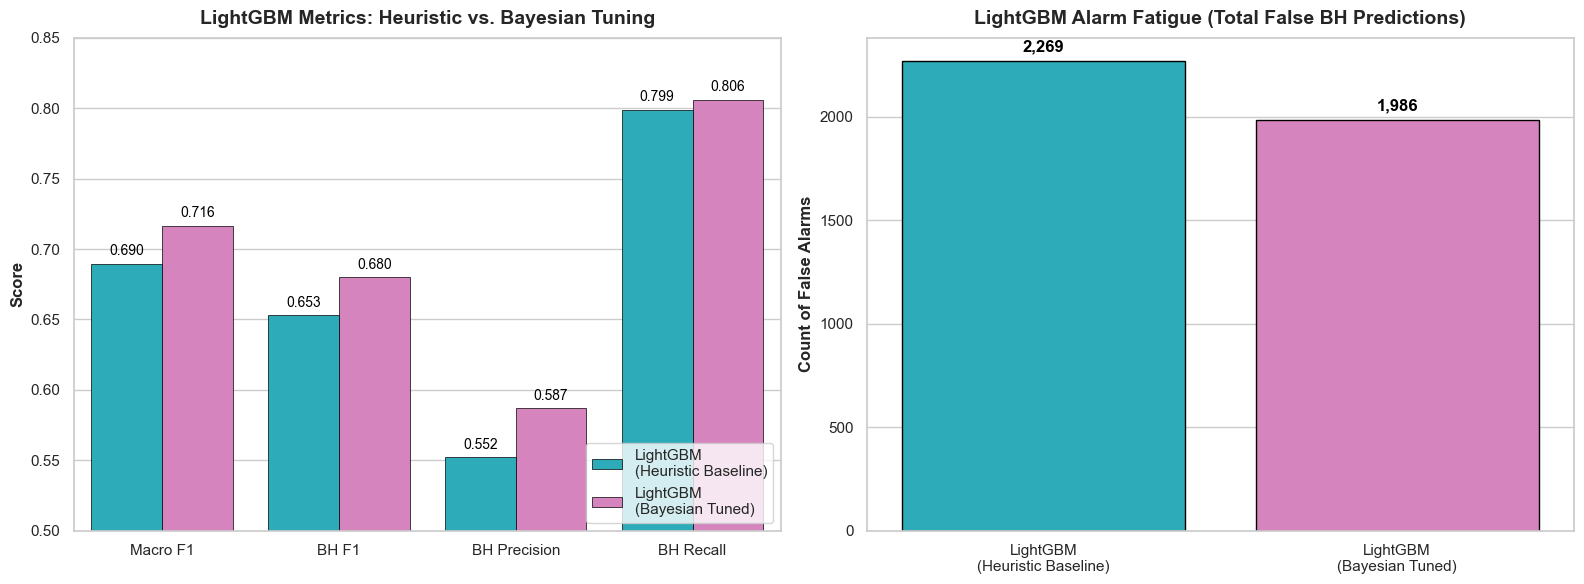

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_lightgbm_comparison():
    # Data extracted exactly from the provided LightGBM logs
    data = {
        'Model': ['LightGBM\n(Heuristic Baseline)', 'LightGBM\n(Bayesian Tuned)'],
        'Accuracy': [0.7780, 0.8073],
        'Macro F1': [0.6897, 0.7164],
        'BH Precision': [0.552, 0.587],
        'BH Recall': [0.799, 0.806],
        'BH F1': [0.653, 0.680],
        'False Alarms': [2269, 1986] # (NB->BH + DB->BH) -> (2015+254) vs (1687+299)
    }

    df = pd.DataFrame(data)

    # Set plotting style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Predictive Metrics Comparison
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(1, 2, 1)
    df_metrics = df[['Model', 'Macro F1', 'BH F1', 'BH Precision', 'BH Recall']].melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', palette=['#17becf', '#e377c2'], ax=ax1, edgecolor='black', linewidth=0.5)

    ax1.set_title('LightGBM Metrics: Heuristic vs. Bayesian Tuning', fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylim(0.50, 0.85)

    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')
    ax1.legend(loc='lower right')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: Alarm Fatigue (False Alarms)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='Model', y='False Alarms', palette=['#17becf', '#e377c2'], ax=ax2, edgecolor='black', linewidth=1)

    ax2.set_title('LightGBM Alarm Fatigue (Total False BH Predictions)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')

    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_lightgbm_comparison()

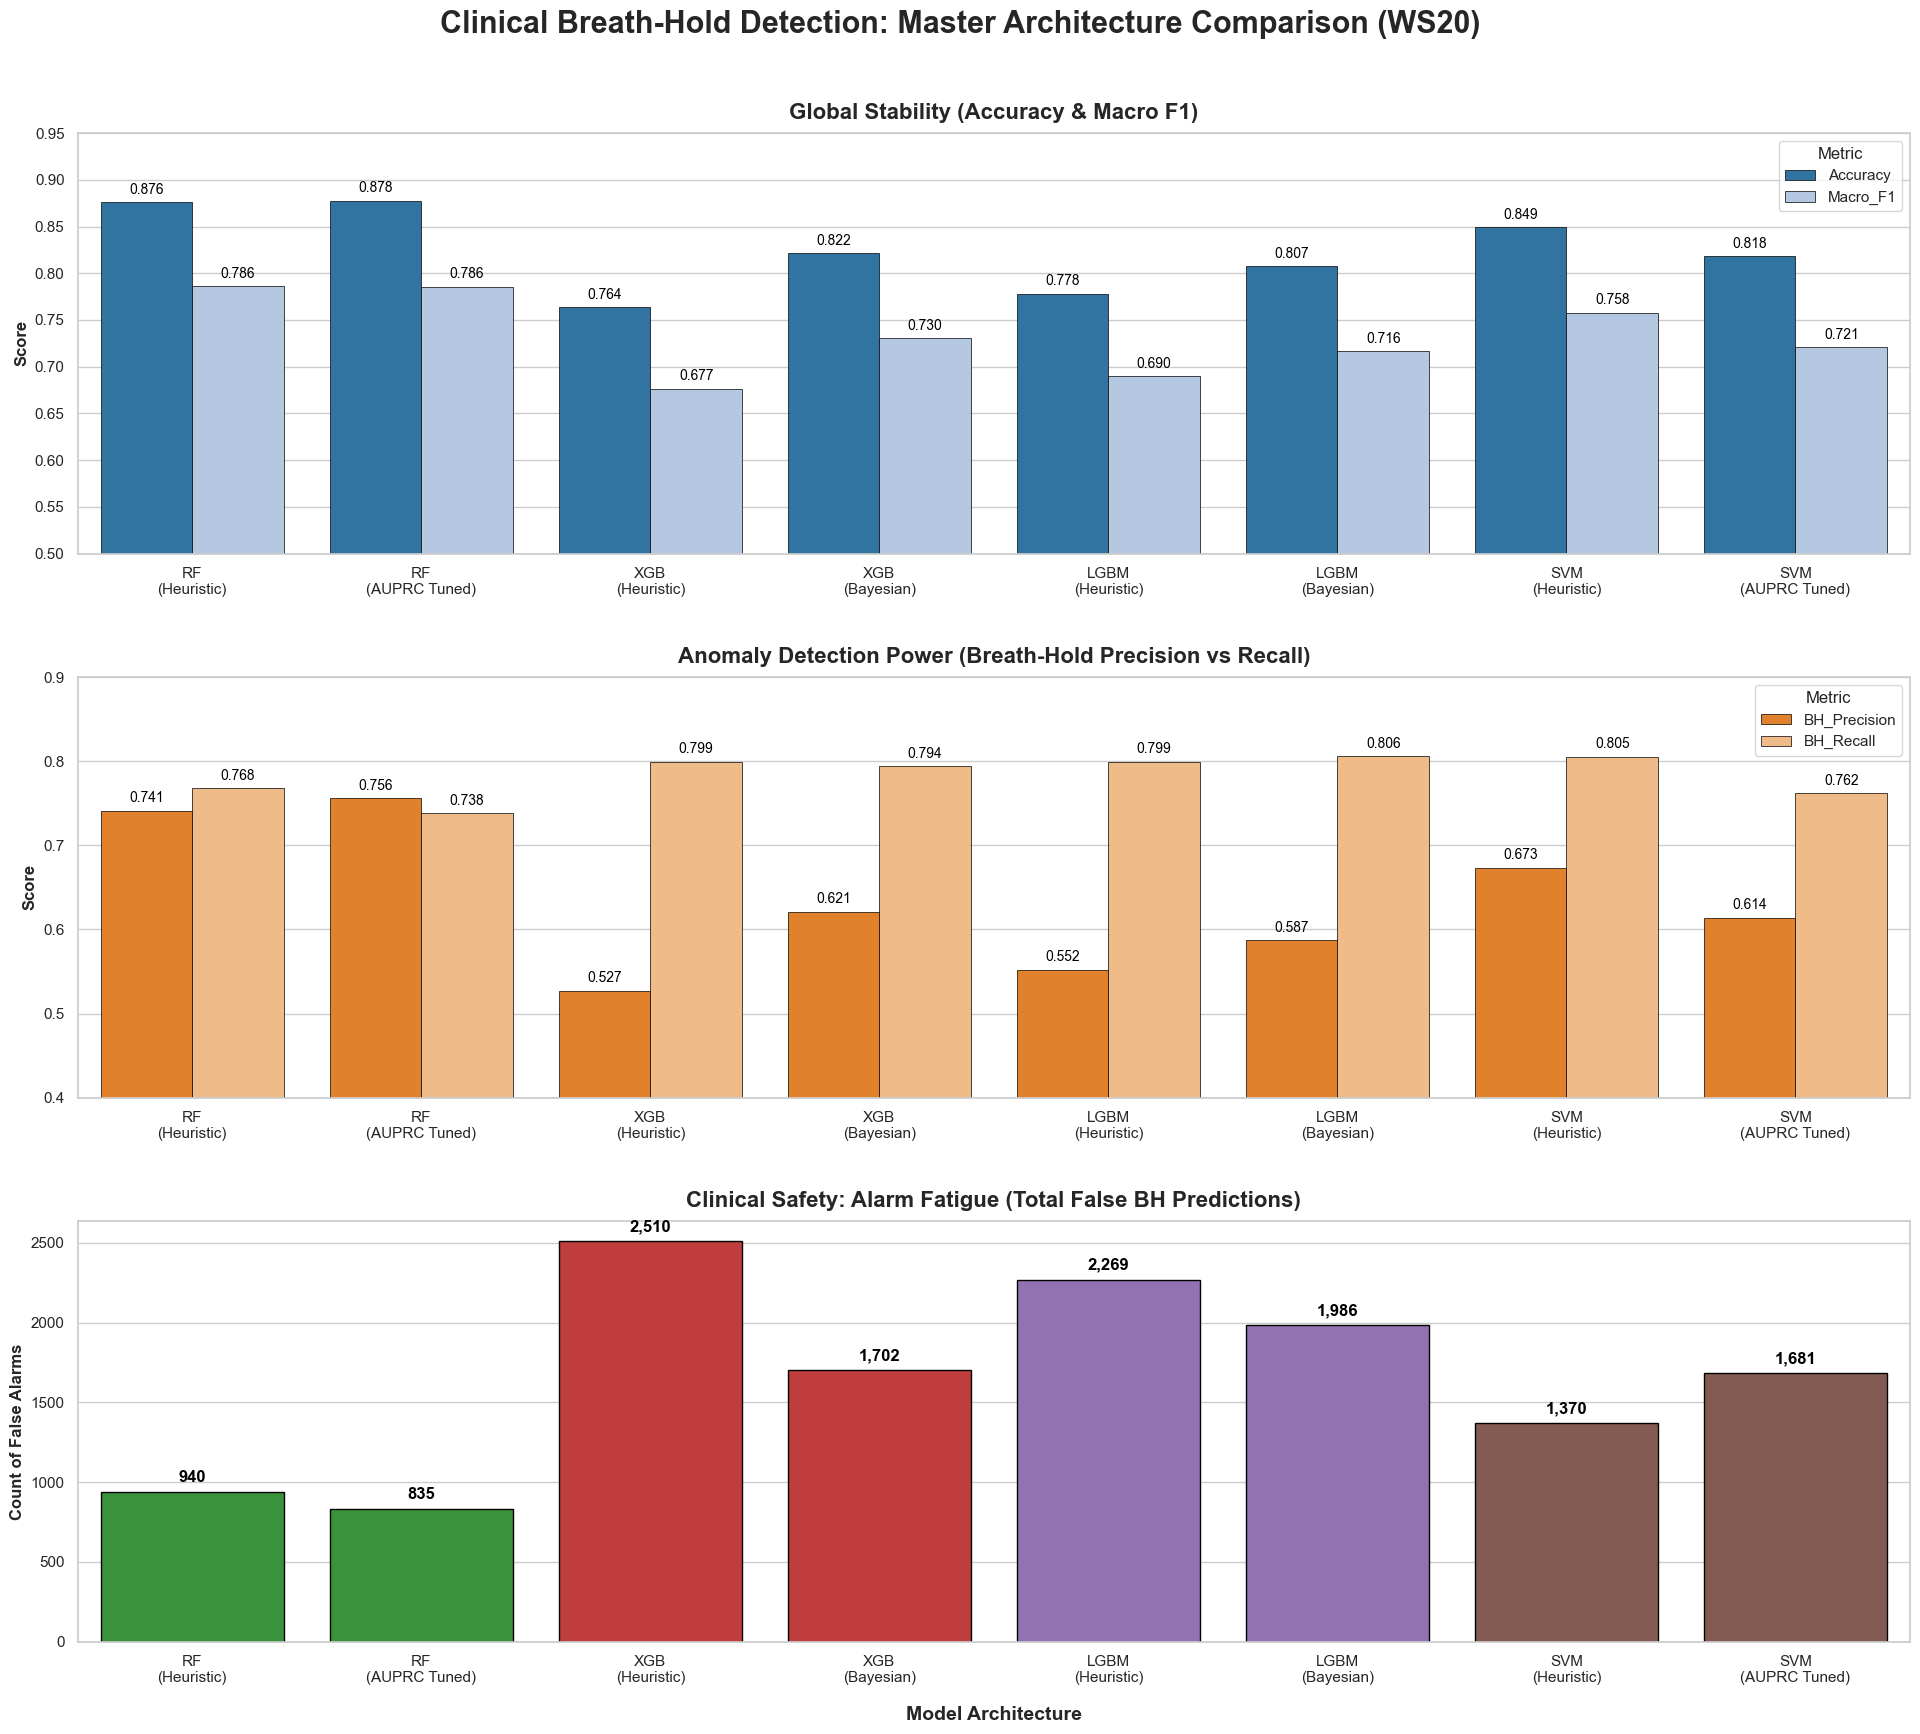

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_master_comparison():
    # Master dataset compiled from all 8 clinical experiments
    data = {
        'Model_Family': ['Random Forest', 'Random Forest', 'XGBoost', 'XGBoost', 'LightGBM', 'LightGBM', 'SVM', 'SVM'],
        'Tuning': ['Heuristic', 'AUPRC Tuned', 'Heuristic', 'Bayesian Tuned', 'Heuristic', 'Bayesian Tuned', 'Heuristic', 'AUPRC Tuned'],
        'Model_Label': ['RF\n(Heuristic)', 'RF\n(AUPRC Tuned)', 'XGB\n(Heuristic)', 'XGB\n(Bayesian)', 'LGBM\n(Heuristic)', 'LGBM\n(Bayesian)', 'SVM\n(Heuristic)', 'SVM\n(AUPRC Tuned)'],
        'Accuracy': [0.8759, 0.8777, 0.7636, 0.8215, 0.7780, 0.8073, 0.8492, 0.8183],
        'Macro_F1': [0.7861, 0.7857, 0.6766, 0.7303, 0.6897, 0.7164, 0.7579, 0.7210],
        'BH_Recall': [0.768, 0.738, 0.799, 0.794, 0.799, 0.806, 0.805, 0.762],
        'BH_Precision': [0.741, 0.756, 0.527, 0.621, 0.552, 0.587, 0.673, 0.614],
        'BH_F1': [0.754, 0.747, 0.635, 0.697, 0.653, 0.680, 0.733, 0.680],
        'False_Alarms': [940, 835, 2510, 1702, 2269, 1986, 1370, 1681]
    }

    df = pd.DataFrame(data)

    # Styling configuration
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 18))
    plt.suptitle('Clinical Breath-Hold Detection: Master Architecture Comparison (WS20)', fontsize=22, fontweight='bold', y=0.98)

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 1: Global Performance (Accuracy & Macro F1)
    # ─────────────────────────────────────────────────────────────────────────────
    ax1 = plt.subplot(3, 1, 1)
    df_global = df[['Model_Label', 'Accuracy', 'Macro_F1']].melt(id_vars='Model_Label', var_name='Metric', value_name='Score')
    sns.barplot(data=df_global, x='Model_Label', y='Score', hue='Metric', palette=['#1f77b4', '#aec7e8'], ax=ax1, edgecolor='black', linewidth=0.5)
    
    ax1.set_title('Global Stability (Accuracy & Macro F1)', fontsize=16, fontweight='bold', pad=10)
    ax1.set_ylim(0.5, 0.95)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    
    # Add numeric labels to bars
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 2: The Clinical Trade-Off (BH Precision vs Recall)
    # ─────────────────────────────────────────────────────────────────────────────
    ax2 = plt.subplot(3, 1, 2)
    df_bh = df[['Model_Label', 'BH_Precision', 'BH_Recall']].melt(id_vars='Model_Label', var_name='Metric', value_name='Score')
    sns.barplot(data=df_bh, x='Model_Label', y='Score', hue='Metric', palette=['#ff7f0e', '#ffbb78'], ax=ax2, edgecolor='black', linewidth=0.5)
    
    ax2.set_title('Anomaly Detection Power (Breath-Hold Precision vs Recall)', fontsize=16, fontweight='bold', pad=10)
    ax2.set_ylim(0.4, 0.9)
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')
    
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 4), textcoords='offset points')

    # ─────────────────────────────────────────────────────────────────────────────
    # Panel 3: Alarm Fatigue (False Positives)
    # ─────────────────────────────────────────────────────────────────────────────
    ax3 = plt.subplot(3, 1, 3)
    # Color code by Model Family: RF(Green), XGB(Red), LGBM(Purple), SVM(Brown)
    colors = ['#2ca02c', '#2ca02c', '#d62728', '#d62728', '#9467bd', '#9467bd', '#8c564b', '#8c564b']
    sns.barplot(data=df, x='Model_Label', y='False_Alarms', palette=colors, ax=ax3, edgecolor='black', linewidth=1)
    
    ax3.set_title('Clinical Safety: Alarm Fatigue (Total False BH Predictions)', fontsize=16, fontweight='bold', pad=10)
    ax3.set_ylabel('Count of False Alarms', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Model Architecture', fontsize=14, fontweight='bold', labelpad=15)
    
    for p in ax3.patches:
        ax3.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

    plt.tight_layout(pad=3.0)
    plt.show()

if __name__ == "__main__":
    plot_master_comparison()